# Delhivery: ETA, Delay, and Delay Propagation Prediction — Group 12 GNN

The notebook inherits the entire preprocessing pipeline, chronological split, leakage guard, and ground truth of the `v6.3-group-9` version, but this run focuses only on the **delay propagation task** with 8 Graph Neural Network models:

- Graph Convolutional Network (GCN)
- Graph Attention Network (GAT)
- GraphSAGE
- Message Passing Neural Network (MPNN)
- Temporal Graph Network (TGN)
- Spatio-Temporal Graph Convolutional Network (ST-GCN)
- Graph Transformer
- Diffusion Convolutional Recurrent Neural Network (DCRNN)

### Group 12 Principles

- The old ETA, delay magnitude, severe-delay classification, and sequential propagation models are kept commented out / as a snapshot and **are not retrained**.
- Each prefix from the first checkpoint to the current checkpoint is turned into a directed sequence graph.
- Nodes represent observed stages/segments; edges connect two consecutive stages in the journey.
- No node or edge from beyond the checkpoint currently being predicted is used.
- All 8 Group 12 models are run in full on the entire fit/validation prefix set; no trip, prefix, or checkpoint is sub-sampled.
- Each model trains for exactly **60 epochs**, with no early stopping and no restoring of an old checkpoint.
- Only the validation-winning model is refit on the full external train set before the final-test evaluation.
- The GNNs are implemented in pure PyTorch so the notebook does not depend on `torch-geometric` or `DGL`.


## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Data Loading](#2-data-loading)
3. [Data Quality Assessment](#3-data-quality-assessment)
4. [Preprocessing](#4-preprocessing)
5. [Aggregation: Segment → Leg → Trip](#5-aggregation-segment--leg--trip)
6. [EDA](#6-eda)
7. [Feature Engineering](#7-feature-engineering)
8. [Data Splitting and Leakage Prevention](#8-data-splitting-and-leakage-prevention)
9. [ETA Regression — Old Model Commented Out](#9-eta-regression--old-model-commented-out)
10. [Delay Magnitude — Old Model Commented Out](#10-delay-magnitude--old-model-commented-out)
11. [Severe-Delay Classification — Old Model Commented Out](#11-severe-delay-classification--old-model-commented-out)
12. [Delay Propagation — Group 12 GNN](#12-delay-propagation--group-12-graph-neural-network)
13. [Explainability — Temporarily Commented Out](#13-explainability-with-limeshap--temporarily-commented-out)
14. [Single-Shipment Trajectory Example](#14-single-shipment-delay-propagation-trajectory-example)
15. [Model Export and Conclusion](#15-model-export-and-conclusion)


## 1. Environment Setup


Core packages:

```bash
pip install pandas numpy scipy matplotlib seaborn scikit-learn xgboost joblib torch
```

- The 8 Group 12 GNNs are implemented in pure PyTorch; installing `torch-geometric` or `DGL` is not required.
- The GPU is used automatically if `torch.cuda.is_available()`.
- There is no fast-benchmark mode, no sub-sampling of trips/checkpoints/prefixes, and no graph truncation.
- Dynamic padding only reduces per-batch padding overhead; it does not drop any real node.
- Old models are kept only as code comments or result snapshots; no old fit command is executed.
- LIME/SHAP remain commented out so they do not slow down the Group 12 benchmark.


In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('torch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch'])
    print('Installed: torch')
else:
    print('Available: torch')


Available: torch


In [2]:
from pathlib import Path
import os

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')
from dataclasses import dataclass
from typing import Callable, Optional
import gc
import importlib.util
import inspect
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.special import expit

from IPython.display import display

from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.neighbors import (
    KNeighborsRegressor, KNeighborsClassifier,
    RadiusNeighborsRegressor, RadiusNeighborsClassifier,
)
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    ExtraTreesRegressor,
    ExtraTreesClassifier,
    AdaBoostRegressor,
    AdaBoostClassifier,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
    HistGradientBoostingRegressor,
    HistGradientBoostingClassifier,
    BaggingRegressor,
    BaggingClassifier,
)
from sklearn.svm import SVR, SVC, LinearSVR, LinearSVC, NuSVR, NuSVC
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    ARDRegression,
    HuberRegressor,
    TheilSenRegressor,
    RANSACRegressor,
    QuantileRegressor,
    PoissonRegressor,
    GammaRegressor,
    TweedieRegressor,
    SGDRegressor,
    PassiveAggressiveRegressor,
    LogisticRegression,
    SGDClassifier,
    PassiveAggressiveClassifier,
)
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    root_mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBRegressor, XGBClassifier

OPTIONAL_DEPENDENCIES = {}

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
    OPTIONAL_DEPENDENCIES['lightgbm'] = (True, '')
except Exception as exc:
    LGBMRegressor = LGBMClassifier = None
    OPTIONAL_DEPENDENCIES['lightgbm'] = (False, f'{type(exc).__name__}: {exc}')

try:
    from catboost import CatBoostRegressor, CatBoostClassifier
    OPTIONAL_DEPENDENCIES['catboost'] = (True, '')
except Exception as exc:
    CatBoostRegressor = CatBoostClassifier = None
    OPTIONAL_DEPENDENCIES['catboost'] = (False, f'{type(exc).__name__}: {exc}')

try:
    from ngboost import NGBRegressor, NGBClassifier
    OPTIONAL_DEPENDENCIES['ngboost'] = (True, '')
except Exception as exc:
    NGBRegressor = NGBClassifier = None
    OPTIONAL_DEPENDENCIES['ngboost'] = (False, f'{type(exc).__name__}: {exc}')

try:
    from interpret.glassbox import ExplainableBoostingRegressor, ExplainableBoostingClassifier
    OPTIONAL_DEPENDENCIES['interpret'] = (True, '')
except Exception as exc:
    ExplainableBoostingRegressor = ExplainableBoostingClassifier = None
    OPTIONAL_DEPENDENCIES['interpret'] = (False, f'{type(exc).__name__}: {exc}')

try:
    from imblearn.ensemble import (
        BalancedRandomForestClassifier,
        EasyEnsembleClassifier,
        RUSBoostClassifier,
    )
    OPTIONAL_DEPENDENCIES['imbalanced_learn'] = (True, '')
except Exception as exc:
    BalancedRandomForestClassifier = EasyEnsembleClassifier = RUSBoostClassifier = None
    OPTIONAL_DEPENDENCIES['imbalanced_learn'] = (False, f'{type(exc).__name__}: {exc}')

BART_BACKEND = None
BART_CLASS = None
try:
    from ISLP.bart import BART as ISLP_BART
    BART_BACKEND = 'ISLP'
    BART_CLASS = ISLP_BART
    OPTIONAL_DEPENDENCIES['bart'] = (True, 'ISLP.bart.BART')
except Exception as islp_exc:
    try:
        from bartpy.sklearnmodel import SklearnModel as BartPyModel
        BART_BACKEND = 'bartpy'
        BART_CLASS = BartPyModel
        OPTIONAL_DEPENDENCIES['bart'] = (True, 'bartpy.sklearnmodel.SklearnModel')
    except Exception as bartpy_exc:
        OPTIONAL_DEPENDENCIES['bart'] = (
            False,
            f'ISLP: {type(islp_exc).__name__}: {islp_exc}; '
            f'bartpy: {type(bartpy_exc).__name__}: {bartpy_exc}'
        )


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
DELAY_THRESHOLD_MINUTES = 120
N_JOBS = 2


optional_status_df = pd.DataFrame([
    {
        'Dependency': name,
        'Available': status[0],
        'Backend / error': status[1],
    }
    for name, status in OPTIONAL_DEPENDENCIES.items()
])
display(optional_status_df.style.set_caption('Optional dependency status'))

,Dependency,Available,Backend / error
0,lightgbm,True,
1,catboost,True,
2,ngboost,False,ModuleNotFoundError: No module named 'ngboost'
3,interpret,False,ModuleNotFoundError: No module named 'interpret'
4,imbalanced_learn,True,
5,bart,False,ISLP: ModuleNotFoundError: No module named 'ISLP'; bartpy: ModuleNotFoundError: No module named 'bartpy'


## 2. Data Loading


On Kaggle, the dataset is loaded directly from the `/kaggle/input` path. The cell below prioritizes the user-supplied path and falls back to local paths when running locally.


In [3]:
KAGGLE_DATA_PATH = Path(
    '/kaggle/input/datasets/santanukundu/delhivery-dataset/delhivery_data.csv'
)


def find_data_path(filename='delhivery_data.csv'):
    candidates = [
        KAGGLE_DATA_PATH,
        Path('/kaggle/input/delhivery-dataset') / filename,
        Path(filename),
        Path('data') / filename,
        Path('Delhivery-Logistics-Shipment-Data-Analysis-main') / filename,
        Path('repo2') / 'Delhivery-Logistics-Shipment-Data-Analysis-main' / filename,
    ]

    for path in candidates:
        if path.exists():
            return path.resolve()

    matches = list(Path.cwd().glob(f'**/{filename}'))
    if matches:
        return matches[0].resolve()

    checked = '\n'.join(f'- {path}' for path in candidates)
    raise FileNotFoundError(
        f'Không tìm thấy {filename}. Các đường dẫn đã kiểm tra:\n{checked}'
    )


DATA_PATH = find_data_path()
print(f'Data path: {DATA_PATH}')

raw_df = pd.read_csv(DATA_PATH)
print(f'Raw shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns')
display(raw_df.head())


Data path: /kaggle/input/datasets/santanukundu/delhivery-dataset/delhivery_data.csv
Raw shape: 144,867 rows × 24 columns


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,9,2018-09-20 04:27:55,10.436,14.000,11.000,11.965,1.273,14.000,11.000,11.965,1.273
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,18,2018-09-20 04:17:55,18.937,24.000,20.000,21.724,1.200,10.000,9.000,9.759,1.111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,27,2018-09-20 04:01:19.505586,27.637,40.000,28.000,32.539,1.429,16.000,7.000,10.815,2.286
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,36,2018-09-20 03:39:57,36.118,62.000,40.000,45.562,1.550,21.000,12.000,13.022,1.750
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,False,39,2018-09-20 03:33:55,39.386,68.000,44.000,54.218,1.545,6.000,5.000,3.915,1.200


### Condensed Data Dictionary

| Category | Main Fields | Purpose |
|---|---|---|
| ID | `trip_uuid`, `route_schedule_uuid` | Identify the trip and route schedule |
| Route | `source_*`, `destination_*`, `route_type` | Geographic and transport-type features |
| Ground truth | `od_start_time`, `od_end_time` | Compute the actual duration and final ETA |
| Plan | `osrm_time`, `osrm_distance`, `segment_osrm_*` | Routing baseline used to compute the proxy delay |
| Dynamic actuals | `segment_actual_time`, `cutoff_timestamp` | Only usable after the checkpoint has occurred |
| Audit | `actual_time`, `factor`, `segment_factor` | Not used as a start-of-trip target/feature because of leakage risk or because it does not represent the full elapsed time |


## 3. Data Quality Assessment


In [4]:
quality_summary = pd.DataFrame({
    'dtype': raw_df.dtypes.astype(str),
    'missing_count': raw_df.isna().sum(),
    'missing_pct': raw_df.isna().mean().mul(100),
    'n_unique': raw_df.nunique(dropna=False),
}).sort_values('missing_pct', ascending=False)

display(quality_summary)

print(f'Exact duplicate rows: {raw_df.duplicated().sum():,}')
print(f'Unique trips: {raw_df["trip_uuid"].nunique():,}')
print(f'Negative segment_actual_time rows: {(raw_df["segment_actual_time"] < 0).sum():,}')
print(f'Non-positive segment_osrm_time rows: {(raw_df["segment_osrm_time"] <= 0).sum():,}')

,dtype,missing_count,missing_pct,n_unique
source_name,object,293,0.202,1499
destination_name,object,261,0.180,1469
route_schedule_uuid,object,0,0.000,1504
data,object,0,0.000,2
route_type,object,0,0.000,2
trip_uuid,object,0,0.000,14817
source_center,object,0,0.000,1508
trip_creation_time,object,0,0.000,14817
destination_center,object,0,0.000,1481
od_start_time,object,0,0.000,26369


Exact duplicate rows: 0
Unique trips: 14,817
Negative segment_actual_time rows: 21
Non-positive segment_osrm_time rows: 2,347


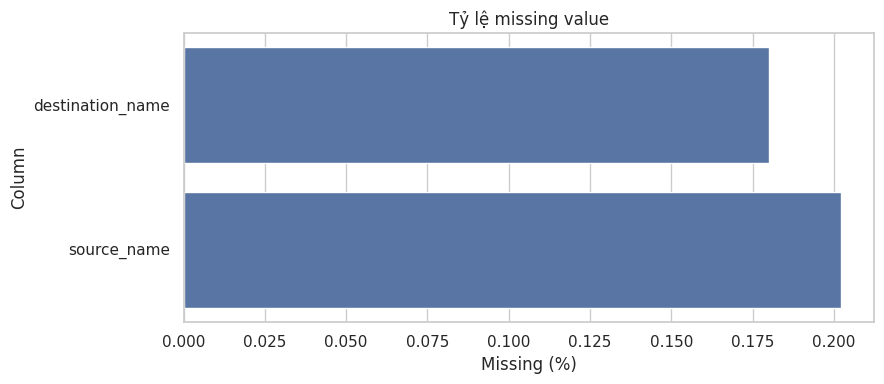

In [5]:
missing = quality_summary.query('missing_count > 0').sort_values('missing_pct')
if not missing.empty:
    plt.figure(figsize=(9, 4))
    sns.barplot(data=missing.reset_index(), x='missing_pct', y='index', color='C0')
    plt.xlabel('Missing (%)')
    plt.ylabel('Column')
    plt.title('Tỷ lệ missing value')
    plt.tight_layout()
    plt.show()
else:
    print('Không có missing value.')

## 4. Preprocessing


Processing principles:

- Do not modify the original dataframe directly; work on a copy.
- Convert columns to the correct datetime type.
- Fill missing location names with the most common/first name within the same `center`, then fall back to the center code.
- Split `city` and `state` out of the location name.
- Keep anomaly flags instead of removing all logistics outliers, since long trips or large delays may be genuine data.


In [6]:
df = raw_df.copy()
df = df.drop_duplicates().reset_index(drop=True)

DATETIME_COLUMNS = [
    'trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp'
]


def parse_mixed_datetime(series):
    """Parse timestamp có/không có microseconds mà không làm mất dữ liệu hợp lệ."""
    try:
        return pd.to_datetime(series, format='mixed', errors='coerce')
    except TypeError:
        return pd.to_datetime(series, errors='coerce')


for col in DATETIME_COLUMNS:
    df[col] = parse_mixed_datetime(df[col])

df['source_name'] = (
    df['source_name']
      .fillna(df.groupby('source_center')['source_name'].transform('first'))
      .fillna(df['source_center'])
)
df['destination_name'] = (
    df['destination_name']
      .fillna(df.groupby('destination_center')['destination_name'].transform('first'))
      .fillna(df['destination_center'])
)


def extract_city(series):
    return series.astype(str).str.split('_').str[0].str.strip()


def extract_state(series):
    return (
        series.astype(str)
              .str.extract(r'\(([^()]*)\)\s*$', expand=False)
              .fillna('Unknown')
              .str.strip()
    )


df['source_city'] = extract_city(df['source_name'])
df['destination_city'] = extract_city(df['destination_name'])
df['source_state'] = extract_state(df['source_name'])
df['destination_state'] = extract_state(df['destination_name'])

df['negative_segment_time_flag'] = (df['segment_actual_time'] < 0).astype(int)
df['zero_segment_plan_flag'] = (df['segment_osrm_time'] <= 0).astype(int)
df['_row_order'] = np.arange(len(df))

print('Remaining missing values:')
display(df.isna().sum()[df.isna().sum() > 0])
print(f"Missing cutoff_timestamp after mixed parsing: {df['cutoff_timestamp'].isna().sum():,}")
display(df.head())

Remaining missing values:


Series([], dtype: int64)

Missing cutoff_timestamp after mixed parsing: 0


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,source_city,destination_city,source_state,destination_state,negative_segment_time_flag,zero_segment_plan_flag,_row_order
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,9,2018-09-20 04:27:55.000000,10.436,14.000,11.000,11.965,1.273,14.000,11.000,11.965,1.273,Anand,Khambhat,Gujarat,Gujarat,0,0,0
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,18,2018-09-20 04:17:55.000000,18.937,24.000,20.000,21.724,1.200,10.000,9.000,9.759,1.111,Anand,Khambhat,Gujarat,Gujarat,0,0,1
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,27,2018-09-20 04:01:19.505586,27.637,40.000,28.000,32.539,1.429,16.000,7.000,10.815,2.286,Anand,Khambhat,Gujarat,Gujarat,0,0,2
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,36,2018-09-20 03:39:57.000000,36.118,62.000,40.000,45.562,1.550,21.000,12.000,13.022,1.750,Anand,Khambhat,Gujarat,Gujarat,0,0,3
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,False,39,2018-09-20 03:33:55.000000,39.386,68.000,44.000,54.218,1.545,6.000,5.000,3.915,1.200,Anand,Khambhat,Gujarat,Gujarat,0,0,4


## 5. Aggregation: Segment → Leg → Trip


The raw dataset has multiple checkpoints for the same leg and multiple legs for the same trip. Training directly on individual rows could let checkpoints from the same trip fall into both train and test, artificially inflating the metric.

Aggregation pipeline:

1. **Checkpoint row**: a dynamic observation recorded during the journey.
2. **Leg**: rows sharing `trip_uuid + source + destination + od_start_time`.
3. **Trip**: a single row for each `trip_uuid`.

Checkpoints are sorted by `cutoff_timestamp`. Cumulative fields at the leg level use `max`; incremental fields use `sum`. The final ground truth is not taken from `actual_time`, but is computed from the trip's start/end timestamps.


In [7]:
df_sorted = df.sort_values(
    ['trip_uuid', 'od_start_time', 'cutoff_timestamp', '_row_order'],
    na_position='last',
).copy()

leg_keys = ['trip_uuid', 'source_center', 'destination_center', 'od_start_time']

leg_df = df_sorted.groupby(leg_keys, as_index=False).agg(
    data=('data', 'first'),
    route_schedule_uuid=('route_schedule_uuid', 'first'),
    route_type=('route_type', 'first'),
    trip_creation_time=('trip_creation_time', 'first'),
    source_name=('source_name', 'first'),
    destination_name=('destination_name', 'last'),
    source_city=('source_city', 'first'),
    destination_city=('destination_city', 'last'),
    source_state=('source_state', 'first'),
    destination_state=('destination_state', 'last'),
    od_end_time=('od_end_time', 'max'),
    start_scan_to_end_scan=('start_scan_to_end_scan', 'max'),
    actual_distance_to_destination=('actual_distance_to_destination', 'max'),
    actual_time=('actual_time', 'max'),
    osrm_time=('osrm_time', 'max'),
    osrm_distance=('osrm_distance', 'max'),
    segment_actual_time=('segment_actual_time', 'sum'),
    segment_osrm_time=('segment_osrm_time', 'sum'),
    segment_osrm_distance=('segment_osrm_distance', 'sum'),
    checkpoint_count=('trip_uuid', 'size'),
    cutoff_rate=('is_cutoff', 'mean'),
    anomaly_count=('negative_segment_time_flag', 'sum'),
    zero_plan_count=('zero_segment_plan_flag', 'sum'),
)

leg_df = leg_df.sort_values(['trip_uuid', 'od_start_time']).reset_index(drop=True)
print(f'Leg-level shape: {leg_df.shape}')
display(leg_df.head())

Leg-level shape: (26369, 27)


,trip_uuid,source_center,destination_center,od_start_time,data,route_schedule_uuid,route_type,trip_creation_time,source_name,destination_name,source_city,destination_city,source_state,destination_state,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,checkpoint_count,cutoff_rate,anomaly_count,zero_plan_count
0,trip-153671041653548748,IND462022AAA,IND209304AAA,2018-09-12 00:00:16.535741,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc60074b,FTL,2018-09-12 00:00:16.535741,Bhopal_Trnsport_H (Madhya Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),Bhopal,Kanpur,Madhya Pradesh,Uttar Pradesh,2018-09-12 16:39:46.858469,999.000,440.974,830.000,394.000,544.803,820.000,474.000,649.853,21,0.952,0,0
1,trip-153671041653548748,IND209304AAA,IND000000ACB,2018-09-12 16:39:46.858469,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc60074b,FTL,2018-09-12 00:00:16.535741,Kanpur_Central_H_6 (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),Kanpur,Gurgaon,Uttar Pradesh,Haryana,2018-09-13 13:40:23.123744,"1,260.000",383.759,732.000,349.000,446.550,728.000,534.000,670.620,18,0.944,0,0
2,trip-153671042288605164,IND572101AAA,IND561203AAB,2018-09-12 00:00:22.886430,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0d68b9,Carting,2018-09-12 00:00:22.886430,Tumkur_Veersagr_I (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),Tumkur,Doddablpur,Karnataka,Karnataka,2018-09-12 02:03:09.655591,122.000,48.543,96.000,42.000,56.912,95.000,39.000,55.990,6,0.833,0,0
3,trip-153671042288605164,IND561203AAB,IND562101AAA,2018-09-12 02:03:09.655591,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0d68b9,Carting,2018-09-12 00:00:22.886430,Doddablpur_ChikaDPP_D (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),Doddablpur,Chikblapur,Karnataka,Karnataka,2018-09-12 03:01:59.598855,58.000,24.644,47.000,26.000,28.199,46.000,26.000,28.200,3,0.667,0,0
4,trip-153671043369099517,IND562132AAA,IND000000ACB,2018-09-12 00:00:33.691250,training,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e5720d,FTL,2018-09-12 00:00:33.691250,Bangalore_Nelmngla_H (Karnataka),Gurgaon_Bilaspur_HB (Haryana),Bangalore,Gurgaon,Karnataka,Haryana,2018-09-14 03:40:17.106733,"3,099.000","1,689.965","2,736.000","1,529.000","2,090.874","2,700.000","1,710.000","2,227.527",77,0.987,0,0


In [8]:
trip_df = leg_df.groupby('trip_uuid', as_index=False).agg(
    data=('data', 'first'),
    route_schedule_uuid=('route_schedule_uuid', 'first'),
    route_type=('route_type', 'first'),
    trip_creation_time=('trip_creation_time', 'first'),
    source_center=('source_center', 'first'),
    destination_center=('destination_center', 'last'),
    source_name=('source_name', 'first'),
    destination_name=('destination_name', 'last'),
    source_city=('source_city', 'first'),
    destination_city=('destination_city', 'last'),
    source_state=('source_state', 'first'),
    destination_state=('destination_state', 'last'),
    trip_start_time=('od_start_time', 'min'),
    trip_end_time=('od_end_time', 'max'),
    leg_count=('trip_uuid', 'size'),
    checkpoint_count=('checkpoint_count', 'sum'),
    start_scan_to_end_scan=('start_scan_to_end_scan', 'sum'),
    actual_distance_to_destination=('actual_distance_to_destination', 'sum'),
    actual_time=('actual_time', 'sum'),
    osrm_time=('osrm_time', 'sum'),
    osrm_distance=('osrm_distance', 'sum'),
    segment_actual_time=('segment_actual_time', 'sum'),
    segment_osrm_time=('segment_osrm_time', 'sum'),
    segment_osrm_distance=('segment_osrm_distance', 'sum'),
    cutoff_rate=('cutoff_rate', 'mean'),
    anomaly_count=('anomaly_count', 'sum'),
    zero_plan_count=('zero_plan_count', 'sum'),
)

trip_df['trip_duration_minutes'] = (
    trip_df['trip_end_time'] - trip_df['trip_start_time']
).dt.total_seconds() / 60

trip_df = trip_df.query(
    'trip_duration_minutes > 0 and osrm_time > 0 and osrm_distance > 0'
).copy()
trip_df = trip_df.sort_values('trip_creation_time').reset_index(drop=True)

print(f'Trip-level shape: {trip_df.shape}')
print(f'Unique trip_uuid after aggregation: {trip_df.trip_uuid.nunique():,}')
display(trip_df.head())

Trip-level shape: (14817, 29)
Unique trip_uuid after aggregation: 14,817


,trip_uuid,data,route_schedule_uuid,route_type,trip_creation_time,source_center,destination_center,source_name,destination_name,source_city,destination_city,source_state,destination_state,trip_start_time,trip_end_time,leg_count,checkpoint_count,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,cutoff_rate,anomaly_count,zero_plan_count,trip_duration_minutes
0,trip-153671041653548748,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc60074b,FTL,2018-09-12 00:00:16.535741,IND462022AAA,IND000000ACB,Bhopal_Trnsport_H (Madhya Pradesh),Gurgaon_Bilaspur_HB (Haryana),Bhopal,Gurgaon,Madhya Pradesh,Haryana,2018-09-12 00:00:16.535741,2018-09-13 13:40:23.123744,2,39,"2,259.000",824.733,"1,562.000",743.000,991.352,"1,548.000","1,008.000","1,320.473",0.948,0,0,"2,260.110"
1,trip-153671042288605164,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0d68b9,Carting,2018-09-12 00:00:22.886430,IND572101AAA,IND562101AAA,Tumkur_Veersagr_I (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),Tumkur,Chikblapur,Karnataka,Karnataka,2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,2,9,180.000,73.187,143.000,68.000,85.111,141.000,65.000,84.189,0.750,0,0,181.612
2,trip-153671043369099517,training,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e5720d,FTL,2018-09-12 00:00:33.691250,IND562132AAA,IND160002AAC,Bangalore_Nelmngla_H (Karnataka),Chandigarh_Mehmdpur_H (Punjab),Bangalore,Chandigarh,Karnataka,Punjab,2018-09-12 00:00:33.691250,2018-09-14 17:34:55.442454,2,89,"3,933.000","1,932.274","3,347.000","1,741.000","2,372.085","3,308.000","1,941.000","2,545.268",0.952,0,0,"3,934.363"
3,trip-153671046011330457,training,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f9f442,Carting,2018-09-12 00:01:00.113710,IND400072AAB,IND401104AAA,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),Mumbai Hub (Maharashtra),Mumbai,Maharashtra,Maharashtra,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,1,2,100.000,17.175,59.000,15.000,19.680,59.000,16.000,19.877,0.500,0,0,100.495
4,trip-153671052974046625,training,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df0613461b0f,FTL,2018-09-12 00:02:09.740725,IND583101AAA,IND583101AAA,Bellary_Dc (Karnataka),Bellary_Dc (Karnataka),Bellary,Bellary,Karnataka,Karnataka,2018-09-12 00:02:09.740725,2018-09-12 12:00:30.683231,3,7,717.000,127.448,341.000,117.000,146.792,340.000,115.000,146.792,0.556,0,0,718.349


In [9]:
trip_df['actual_time_gap_vs_elapsed'] = (
    trip_df['trip_duration_minutes'] - trip_df['actual_time']
)

consistency = pd.DataFrame({
    'metric': [
        'trip_duration vs actual_time (audit only)',
        'actual_time vs segment_actual_time',
        'osrm_time vs segment_osrm_time',
        'osrm_distance vs segment_osrm_distance',
    ],
    'correlation': [
        trip_df['trip_duration_minutes'].corr(trip_df['actual_time']),
        trip_df['actual_time'].corr(trip_df['segment_actual_time']),
        trip_df['osrm_time'].corr(trip_df['segment_osrm_time']),
        trip_df['osrm_distance'].corr(trip_df['segment_osrm_distance']),
    ]
})
display(consistency)

display(
    trip_df['actual_time_gap_vs_elapsed']
           .describe(percentiles=[.25, .5, .75, .9, .95, .99])
           .to_frame('elapsed_minus_actual_time_minutes')
)

,metric,correlation
0,trip_duration vs actual_time (audit only),0.953
1,actual_time vs segment_actual_time,1.000
2,osrm_time vs segment_osrm_time,0.994
3,osrm_distance vs segment_osrm_distance,0.995


,elapsed_minus_actual_time_minutes
count,"14,817.000"
mean,190.323
std,217.054
min,0.184
25%,55.540
50%,117.042
75%,237.548
90%,460.006
95%,631.868
99%,965.492


## 6. EDA


In [10]:
trip_df['actual_eta'] = trip_df['trip_end_time']
trip_df['osrm_eta'] = trip_df['trip_start_time'] + pd.to_timedelta(trip_df['osrm_time'], unit='m')
trip_df['delay_minutes'] = trip_df['trip_duration_minutes'] - trip_df['osrm_time']
trip_df['delay_ratio'] = trip_df['trip_duration_minutes'] / trip_df['osrm_time']

summary_cols = [
    'trip_duration_minutes', 'actual_time', 'osrm_time', 'delay_minutes',
    'osrm_distance', 'leg_count', 'checkpoint_count'
]
display(trip_df[summary_cols].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).T)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
trip_duration_minutes,"14,817.000",547.477,668.687,23.461,93.741,151.158,288.570,673.301,"1,317.830","1,939.872","3,338.654","7,898.552"
actual_time,"14,817.000",357.154,561.406,9.000,42.000,67.000,149.000,370.000,893.000,"1,471.400","2,952.840","6,265.000"
osrm_time,"14,817.000",162.073,272.305,6.000,18.000,29.000,60.000,169.000,389.000,709.200,"1,535.000","2,032.000"
delay_minutes,"14,817.000",385.404,433.278,-8.034,65.440,111.315,215.123,490.991,972.106,"1,282.362","2,030.103","7,687.552"
osrm_distance,"14,817.000",205.104,370.780,9.073,19.338,30.942,65.883,209.300,490.841,969.316,"2,065.163","2,840.081"
leg_count,"14,817.000",1.780,1.203,1.000,1.000,1.000,1.000,2.000,4.000,4.000,6.000,8.000
checkpoint_count,"14,817.000",9.777,13.596,1.000,2.000,3.000,5.000,10.000,21.000,38.000,77.000,101.000


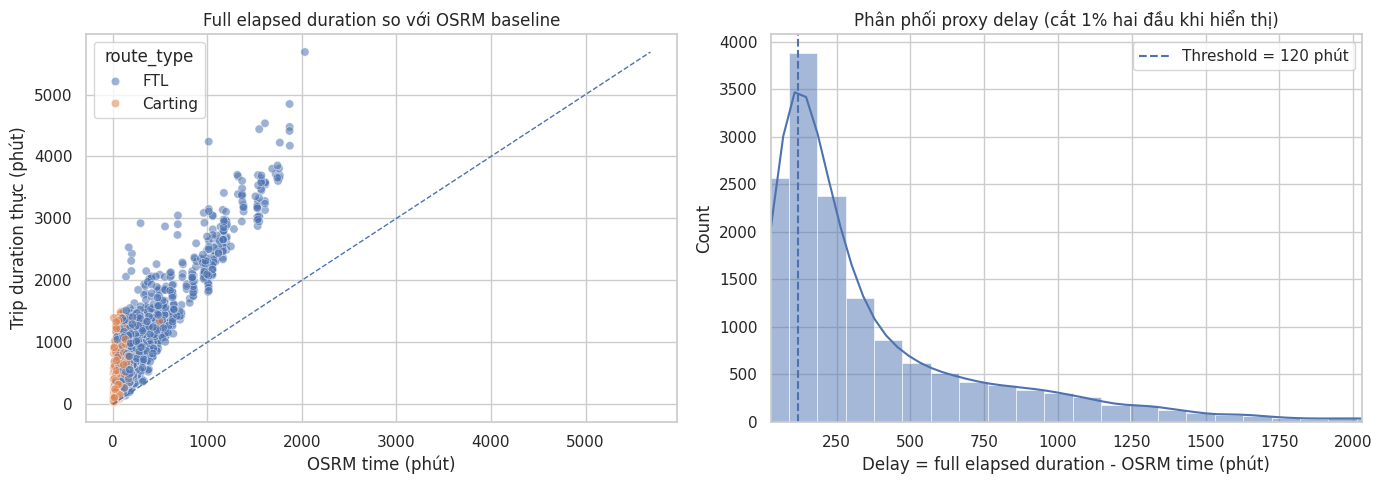

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = trip_df.sample(min(5000, len(trip_df)), random_state=RANDOM_STATE)
sns.scatterplot(
    data=sample, x='osrm_time', y='trip_duration_minutes',
    hue='route_type', alpha=.55, ax=axes[0]
)
max_time = max(sample['osrm_time'].max(), sample['trip_duration_minutes'].max())
axes[0].plot([0, max_time], [0, max_time], linestyle='--', linewidth=1)
axes[0].set_title('Full elapsed duration so với OSRM baseline')
axes[0].set_xlabel('OSRM time (phút)')
axes[0].set_ylabel('Trip duration thực (phút)')

sns.histplot(trip_df['delay_minutes'], bins=80, kde=True, ax=axes[1], color='C0')
axes[1].axvline(
    DELAY_THRESHOLD_MINUTES, linestyle='--',
    label=f'Threshold = {DELAY_THRESHOLD_MINUTES} phút'
)
axes[1].set_xlim(trip_df['delay_minutes'].quantile(.01), trip_df['delay_minutes'].quantile(.99))
axes[1].set_title('Phân phối proxy delay (cắt 1% hai đầu khi hiển thị)')
axes[1].set_xlabel('Delay = full elapsed duration - OSRM time (phút)')
axes[1].legend()

plt.tight_layout()
plt.show()

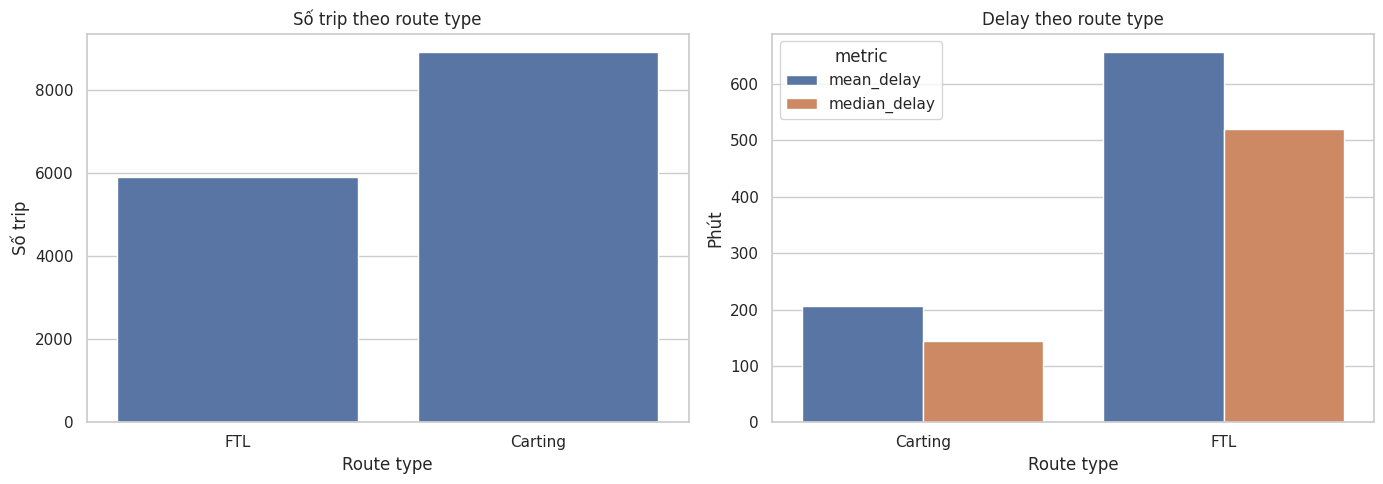

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=trip_df, x='route_type', ax=axes[0], color='C0')
axes[0].set_title('Số trip theo route type')
axes[0].set_xlabel('Route type')
axes[0].set_ylabel('Số trip')

route_delay = (
    trip_df.groupby('route_type', as_index=False)
           .agg(mean_delay=('delay_minutes', 'mean'), median_delay=('delay_minutes', 'median'))
)
route_delay_melt = route_delay.melt('route_type', var_name='metric', value_name='delay_minutes')
sns.barplot(data=route_delay_melt, x='route_type', y='delay_minutes', hue='metric', ax=axes[1], palette='deep')
axes[1].set_title('Delay theo route type')
axes[1].set_xlabel('Route type')
axes[1].set_ylabel('Phút')

plt.tight_layout()
plt.show()

,state_corridor,trips,mean_delay,median_delay,mean_trip_duration
0,Punjab → Karnataka,20,"2,033.478","2,034.250","3,782.328"
1,Haryana → Telangana,26,"1,808.370","1,928.518","3,116.831"
2,Karnataka → Haryana,38,"1,673.450","1,658.819","3,226.345"
3,Haryana → Karnataka,47,"1,572.965","1,517.846","3,116.093"
4,Haryana → West Bengal,32,"1,457.948","1,356.263","2,473.885"
5,West Bengal → Haryana,26,"1,394.229","1,398.169","2,481.421"
6,Delhi → Maharashtra,37,"1,231.963","1,186.976","2,257.314"
7,Gujarat → Karnataka,20,"1,227.181","1,211.308","2,201.731"
8,Haryana → Maharashtra,22,"1,203.878","1,160.248","2,172.741"
9,Maharashtra → Haryana,44,"1,114.545","1,129.711","2,101.681"


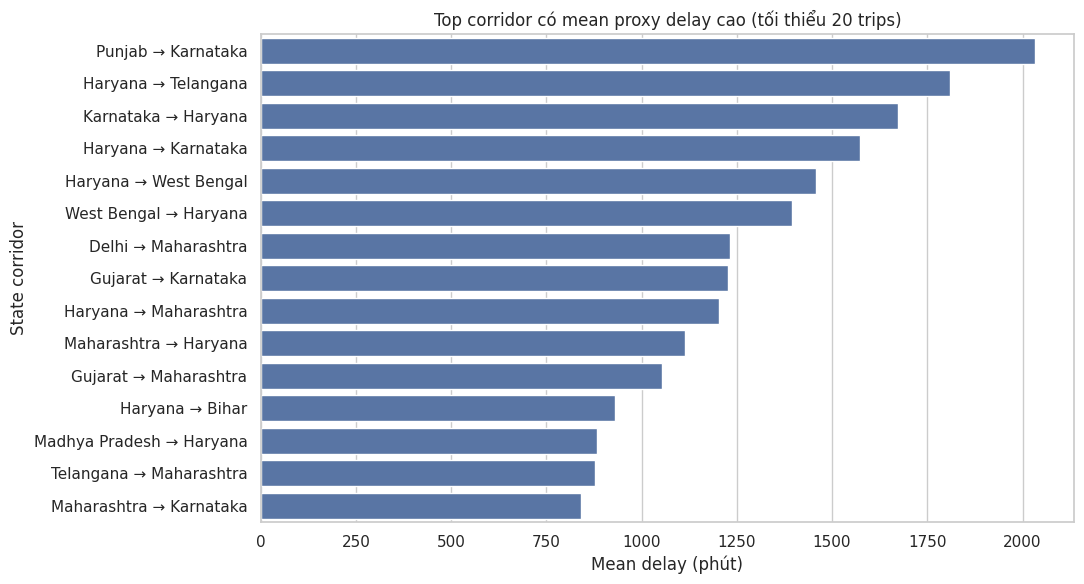

In [13]:
trip_df['state_corridor'] = trip_df['source_state'] + ' → ' + trip_df['destination_state']

corridor_summary = (
    trip_df.groupby('state_corridor')
           .agg(
               trips=('trip_uuid', 'size'),
               mean_delay=('delay_minutes', 'mean'),
               median_delay=('delay_minutes', 'median'),
               mean_trip_duration=('trip_duration_minutes', 'mean'),
           )
           .query('trips >= 20')
           .sort_values('mean_delay', ascending=False)
           .head(15)
           .reset_index()
)

display(corridor_summary)

plt.figure(figsize=(11, 6))
sns.barplot(data=corridor_summary, x='mean_delay', y='state_corridor', color='C0')
plt.title('Top corridor có mean proxy delay cao (tối thiểu 20 trips)')
plt.xlabel('Mean delay (phút)')
plt.ylabel('State corridor')
plt.tight_layout()
plt.show()

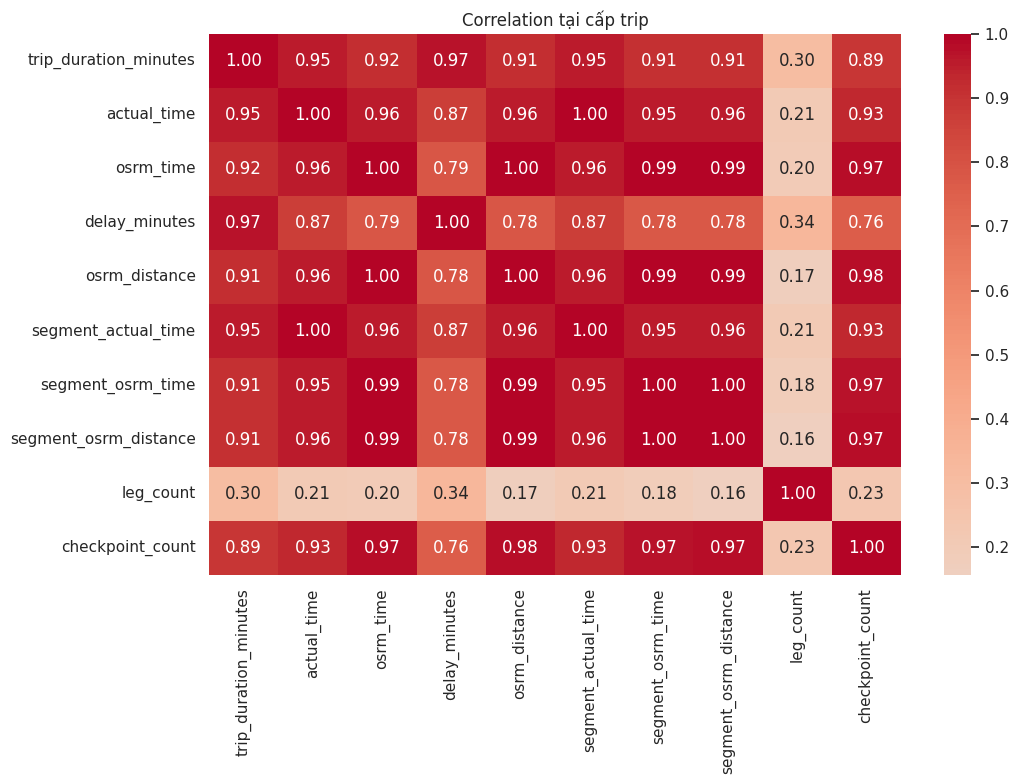

In [14]:
corr_cols = [
    'trip_duration_minutes', 'actual_time', 'osrm_time', 'delay_minutes',
    'osrm_distance', 'segment_actual_time', 'segment_osrm_time',
    'segment_osrm_distance', 'leg_count', 'checkpoint_count'
]
plt.figure(figsize=(11, 8))
sns.heatmap(trip_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation tại cấp trip')
plt.tight_layout()
plt.show()

## 7. Feature Engineering


### Features for the Start-of-Trip Model

Only information guaranteed to be available before or at departure is used:

- the route plan's `osrm_time`, `osrm_distance`;
- origin, destination, and route type;
- departure hour/day;
- ratios computed only from the OSRM plan.

`segment_osrm_*`, `leg_count`, and `checkpoint_count` are not used because they are aggregated from all actual rows and may not be fully known at departure. No actual/cutoff/end-time variable is used.


In [15]:
trip_df['start_hour'] = trip_df['trip_start_time'].dt.hour
trip_df['start_dayofweek'] = trip_df['trip_start_time'].dt.dayofweek
trip_df['start_month'] = trip_df['trip_start_time'].dt.month
trip_df['is_weekend'] = trip_df['start_dayofweek'].isin([5, 6]).astype(int)
trip_df['state_corridor'] = trip_df['source_state'] + ' → ' + trip_df['destination_state']

trip_df['planned_speed_kmph'] = (
    trip_df['osrm_distance'] / (trip_df['osrm_time'] / 60).replace(0, np.nan)
)
trip_df['planned_minutes_per_km'] = (
    trip_df['osrm_time'] / trip_df['osrm_distance'].replace(0, np.nan)
)
trip_df = trip_df.replace([np.inf, -np.inf], np.nan)

START_NUMERIC_FEATURES = [
    'osrm_time', 'osrm_distance',
    'start_hour', 'start_dayofweek', 'start_month', 'is_weekend',
    'planned_speed_kmph', 'planned_minutes_per_km',
]

START_CATEGORICAL_FEATURES = [
    'route_type', 'source_state', 'destination_state', 'state_corridor'
]

START_FEATURES = START_NUMERIC_FEATURES + START_CATEGORICAL_FEATURES

print(f'Number of start-of-trip model features: {len(START_FEATURES)}')
display(trip_df[START_FEATURES + ['trip_duration_minutes', 'delay_minutes']].head())

Number of start-of-trip model features: 12


,osrm_time,osrm_distance,start_hour,start_dayofweek,start_month,is_weekend,planned_speed_kmph,planned_minutes_per_km,route_type,source_state,destination_state,state_corridor,trip_duration_minutes,delay_minutes
0,743.000,991.352,0,2,9,0,80.055,0.749,FTL,Madhya Pradesh,Haryana,Madhya Pradesh → Haryana,"2,260.110","1,517.110"
1,68.000,85.111,0,2,9,0,75.098,0.799,Carting,Karnataka,Karnataka,Karnataka → Karnataka,181.612,113.612
2,"1,741.000","2,372.085",0,2,9,0,81.749,0.734,FTL,Karnataka,Punjab,Karnataka → Punjab,"3,934.363","2,193.363"
3,15.000,19.680,0,2,9,0,78.720,0.762,Carting,Maharashtra,Maharashtra,Maharashtra → Maharashtra,100.495,85.495
4,117.000,146.792,0,2,9,0,75.278,0.797,FTL,Karnataka,Karnataka,Karnataka → Karnataka,718.349,601.349


## 8. Data Splitting and Leakage Prevention


The dataset has a built-in external time-based split:

- `training`: the earlier period;
- `test`: the later period.

The final test set is kept intact and used **only once**, after the model has been selected. Within `training`, the notebook creates an additional chronological 80/20 fit/validation split to compare models and choose the classification threshold.


In [16]:
train_df = trip_df.query("data == 'training'").copy().sort_values('trip_creation_time')
test_df = trip_df.query("data == 'test'").copy().sort_values('trip_creation_time')

trip_overlap = set(train_df['trip_uuid']).intersection(test_df['trip_uuid'])
assert len(trip_overlap) == 0, 'Có trip_uuid trùng giữa external train và test.'

validation_start = int(len(train_df) * 0.80)
fit_df = train_df.iloc[:validation_start].copy()
validation_df = train_df.iloc[validation_start:].copy()

fit_val_overlap = set(fit_df['trip_uuid']).intersection(validation_df['trip_uuid'])
assert len(fit_val_overlap) == 0, 'Có trip_uuid trùng giữa fit và validation.'
assert fit_df['trip_creation_time'].max() <= validation_df['trip_creation_time'].min()

split_summary = pd.DataFrame({
    'split': ['fit', 'validation', 'final test'],
    'n_trips': [len(fit_df), len(validation_df), len(test_df)],
    'pct_all_trips': [len(fit_df)/len(trip_df), len(validation_df)/len(trip_df), len(test_df)/len(trip_df)],
    'start_date': [
        fit_df['trip_creation_time'].min(), validation_df['trip_creation_time'].min(),
        test_df['trip_creation_time'].min()
    ],
    'end_date': [
        fit_df['trip_creation_time'].max(), validation_df['trip_creation_time'].max(),
        test_df['trip_creation_time'].max()
    ],
    'mean_duration': [
        fit_df['trip_duration_minutes'].mean(), validation_df['trip_duration_minutes'].mean(),
        test_df['trip_duration_minutes'].mean()
    ],
    'mean_delay': [fit_df['delay_minutes'].mean(), validation_df['delay_minutes'].mean(), test_df['delay_minutes'].mean()],
})

display(split_summary)
print(f'External train trips: {len(train_df):,} ({len(train_df)/len(trip_df):.2%})')
print(f'Final test trips: {len(test_df):,} ({len(test_df)/len(trip_df):.2%})')
print(f'Trip overlap external train/test: {len(trip_overlap)}')

,split,n_trips,pct_all_trips,start_date,end_date,mean_duration,mean_delay
0,fit,8523,0.575,2018-09-12 00:00:16.535741,2018-09-23 22:15:46.635975,545.265,382.142
1,validation,2131,0.144,2018-09-23 22:16:47.064680,2018-09-26 23:54:27.945614,570.765,399.243
2,final test,4163,0.281,2018-09-27 00:02:18.970980,2018-10-03 23:59:42.701692,540.085,384.998


External train trips: 10,654 (71.90%)
Final test trips: 4,163 (28.10%)
Trip overlap external train/test: 0


### Leakage Guard

The following columns **must not be fed into the start-of-trip ETA model**:

- `actual_time`, `segment_actual_time`, `actual_distance_to_destination`;
- `factor`, `segment_factor`, because they are derived directly from actual/planned time;
- `od_end_time`, `trip_end_time`, `start_scan_to_end_scan`;
- `cutoff_timestamp`, `cutoff_factor`, `cutoff_rate`, if predicting before the trip starts;
- `delay_minutes`, `actual_eta`, because they are the target or derived from the target.


In [17]:
LEAKAGE_COLUMNS = {
    'actual_time', 'segment_actual_time', 'actual_distance_to_destination',
    'factor', 'segment_factor', 'od_end_time', 'trip_end_time',
    'start_scan_to_end_scan', 'cutoff_timestamp', 'cutoff_factor',
    'cutoff_rate', 'delay_minutes', 'delay_ratio', 'actual_eta',
    'trip_duration_minutes', 'actual_time_gap_vs_elapsed',
    'segment_osrm_time', 'segment_osrm_distance', 'leg_count', 'checkpoint_count'
}

leaked = LEAKAGE_COLUMNS.intersection(START_FEATURES)
assert not leaked, f'Feature set chứa biến leakage/future information: {leaked}'
print('Start-of-trip leakage check passed.')

Start-of-trip leakage check passed.


In [18]:
def make_start_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('numeric', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), START_NUMERIC_FEATURES),
            ('categorical', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(
                    handle_unknown='ignore',
                    min_frequency=10,
                    sparse_output=True,
                )),
            ]), START_CATEGORICAL_FEATURES),
        ],
        remainder='drop',
    )


@dataclass(frozen=True)
class ModelSpec:
    name: str
    group: str
    factory: Callable[[], BaseEstimator]
    matrix_kind: str = 'sparse'
    optional_dependency: Optional[str] = None
    note: str = ''


def optional_dependency_available(name):
    if name is None:
        return True, ''
    return OPTIONAL_DEPENDENCIES.get(name, (False, f'Unknown dependency: {name}'))


def make_adaboost_regressor():
    base = DecisionTreeRegressor(
        max_depth=3,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    )
    kwargs = dict(
        n_estimators=180,
        learning_rate=0.04,
        loss='square',
        random_state=RANDOM_STATE,
    )
    try:
        return AdaBoostRegressor(estimator=base, **kwargs)
    except TypeError:
        return AdaBoostRegressor(base_estimator=base, **kwargs)


def make_adaboost_classifier():
    base = DecisionTreeClassifier(
        max_depth=2,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    )
    kwargs = dict(
        n_estimators=180,
        learning_rate=0.04,
        random_state=RANDOM_STATE,
    )
    try:
        return AdaBoostClassifier(estimator=base, **kwargs)
    except TypeError:
        return AdaBoostClassifier(base_estimator=base, **kwargs)


def make_calibrated_classifier(base_estimator):
    """Bổ sung predict_proba cho model chỉ có decision_function."""
    try:
        return CalibratedClassifierCV(estimator=base_estimator, method='sigmoid', cv=3)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=base_estimator, method='sigmoid', cv=3)


def make_ransac_regressor():
    kwargs = dict(
        min_samples=0.5,
        max_trials=100,
        loss='absolute_error',
        random_state=RANDOM_STATE,
    )
    try:
        return RANSACRegressor(estimator=LinearRegression(), **kwargs)
    except TypeError:
        return RANSACRegressor(base_estimator=LinearRegression(), **kwargs)


def make_bart_regressor():
    if BART_BACKEND == 'ISLP':
        return BART_CLASS(
            random_state=RANDOM_STATE,
            burnin=15,
            ndraw=30,
        )
    if BART_BACKEND == 'bartpy':
        return BART_CLASS(
            n_trees=50,
            n_samples=80,
            n_burn=50,
            n_jobs=N_JOBS,
        )
    raise ImportError('Không có backend BART. Cài ISLP hoặc bartpy.')


def regression_model_specs():

    return [
        ModelSpec('Decision Tree Regressor', 'Existing Trees', lambda: DecisionTreeRegressor(
            max_depth=14, min_samples_leaf=3, random_state=RANDOM_STATE)),
        ModelSpec('Random Forest Regressor', 'Existing Trees', lambda: RandomForestRegressor(
            n_estimators=180, max_depth=16, min_samples_leaf=2,
            max_features='sqrt', n_jobs=N_JOBS, random_state=RANDOM_STATE)),
        ModelSpec('Extra Trees Regressor', 'Existing Trees', lambda: ExtraTreesRegressor(
            n_estimators=180, max_depth=None, min_samples_leaf=2,
            max_features=1.0, n_jobs=N_JOBS, random_state=RANDOM_STATE)),
        ModelSpec('AdaBoost Regressor', 'Existing Trees', make_adaboost_regressor, matrix_kind='dense'),

        ModelSpec('Gradient Boosting Regressor', '1. Gradient Boosting', lambda: GradientBoostingRegressor(
            n_estimators=220, learning_rate=0.04, max_depth=3,
            min_samples_leaf=5, subsample=0.85, random_state=RANDOM_STATE), matrix_kind='dense'),
        ModelSpec('HistGradientBoosting Regressor', '1. Gradient Boosting', lambda: HistGradientBoostingRegressor(
            max_iter=240, learning_rate=0.05, max_leaf_nodes=31,
            l2_regularization=1.0, early_stopping=True, random_state=RANDOM_STATE), matrix_kind='dense'),
        ModelSpec('XGBoost Regressor', '1. Gradient Boosting', lambda: XGBRegressor(
            n_estimators=320, max_depth=5, learning_rate=0.05,
            subsample=0.85, colsample_bytree=0.85, objective='reg:squarederror',
            eval_metric='mae', tree_method='hist', n_jobs=N_JOBS, random_state=RANDOM_STATE)),
        ModelSpec('LightGBM Regressor', '1. Gradient Boosting', lambda: LGBMRegressor(
            n_estimators=320, learning_rate=0.04, num_leaves=31,
            subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
            random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=-1),
            optional_dependency='lightgbm'),
        ModelSpec('CatBoost Regressor', '1. Gradient Boosting', lambda: CatBoostRegressor(
            iterations=320, depth=6, learning_rate=0.04,
            loss_function='RMSE', random_seed=RANDOM_STATE, verbose=False,
            allow_writing_files=False, thread_count=N_JOBS),
            optional_dependency='catboost'),
        ModelSpec('NGBoost Regressor', '1. Gradient Boosting', lambda: NGBRegressor(
            n_estimators=220, learning_rate=0.03,
            verbose=False, random_state=RANDOM_STATE), matrix_kind='dense',
            optional_dependency='ngboost',
            note='Probabilistic boosting; huấn luyện trên toàn bộ fit.'),
        ModelSpec('Explainable Boosting Machine Regressor', '1. Gradient Boosting',
            lambda: ExplainableBoostingRegressor(
                max_rounds=1200, interactions=10,
                random_state=RANDOM_STATE, n_jobs=N_JOBS),
            matrix_kind='dense', optional_dependency='interpret',
            note='Explainable Boosting Machine; huấn luyện trên toàn bộ fit.'),
        ModelSpec('BART / GBART Regressor', '1. Gradient Boosting', make_bart_regressor,
            matrix_kind='dense', optional_dependency='bart',
            note='Bayesian Additive Regression Trees; rất nặng.'),
        ModelSpec('DART Regressor', '1. Gradient Boosting', lambda: XGBRegressor(
            booster='dart', n_estimators=260, max_depth=5,
            learning_rate=0.05, subsample=0.85, colsample_bytree=0.85,
            rate_drop=0.10, skip_drop=0.0, objective='reg:squarederror',
            eval_metric='mae', tree_method='hist', n_jobs=N_JOBS,
            random_state=RANDOM_STATE)),

        ModelSpec('SVR', '2. SVM', lambda: SVR(C=10.0, epsilon=0.1, kernel='rbf', gamma='scale'),
            note='Kernel SVR; huấn luyện trên toàn bộ fit.'),
        ModelSpec('LinearSVR', '2. SVM', lambda: LinearSVR(
            C=1.0, epsilon=0.1, max_iter=5000, random_state=RANDOM_STATE)),
        ModelSpec('NuSVR', '2. SVM', lambda: NuSVR(C=10.0, nu=0.5, kernel='rbf', gamma='scale'),
            note='Kernel NuSVR; huấn luyện trên toàn bộ fit.'),

        ModelSpec('Linear Regression', '3. Linear Models', lambda: LinearRegression(n_jobs=N_JOBS)),
        ModelSpec('Ridge Regression', '3. Linear Models', lambda: Ridge(alpha=10.0, solver='lsqr')),
        ModelSpec('Lasso Regression', '3. Linear Models', lambda: Lasso(
            alpha=0.01, max_iter=5000, random_state=RANDOM_STATE)),
        ModelSpec('Elastic Net', '3. Linear Models', lambda: ElasticNet(
            alpha=0.01, l1_ratio=0.5, max_iter=5000, random_state=RANDOM_STATE)),
        ModelSpec('Bayesian Ridge', '3. Linear Models', lambda: BayesianRidge(), matrix_kind='dense'),
        ModelSpec('ARD Regression', '3. Linear Models', lambda: ARDRegression(), matrix_kind='dense'),
        ModelSpec('Huber Regressor', '3. Linear Models', lambda: HuberRegressor(
            epsilon=1.35, alpha=0.0001, max_iter=500), matrix_kind='dense', note='Huấn luyện trên toàn bộ fit.'),
        ModelSpec('Theil-Sen Regressor', '3. Linear Models', lambda: TheilSenRegressor(
            max_subpopulation=10000, n_jobs=N_JOBS,
            random_state=RANDOM_STATE), matrix_kind='dense', note='Estimator robust; huấn luyện trên toàn bộ fit.'),
        ModelSpec('RANSAC Regressor', '3. Linear Models', make_ransac_regressor,
            matrix_kind='dense',
            note='Huấn luyện trên toàn bộ fit.'),
        ModelSpec('Quantile Regression', '3. Linear Models', lambda: QuantileRegressor(
            quantile=0.5, alpha=0.01, solver='highs'), matrix_kind='dense',
            note='Quantile regression bằng linear programming; huấn luyện trên toàn bộ fit.'),
        ModelSpec('Poisson Regressor', '3. Linear Models', lambda: PoissonRegressor(
            alpha=1.0, max_iter=500), matrix_kind='dense'),
        ModelSpec('Gamma Regressor', '3. Linear Models', lambda: GammaRegressor(
            alpha=1.0, max_iter=500), matrix_kind='dense'),
        ModelSpec('Tweedie Regressor', '3. Linear Models', lambda: TweedieRegressor(
            power=1.5, alpha=1.0, max_iter=500), matrix_kind='dense'),
        ModelSpec('SGD Regressor', '3. Linear Models', lambda: SGDRegressor(
            loss='huber', penalty='elasticnet', alpha=0.0001, max_iter=3000,
            early_stopping=True, random_state=RANDOM_STATE)),
        ModelSpec('Passive Aggressive Regressor', '3. Linear Models', lambda: PassiveAggressiveRegressor(
            C=0.1, max_iter=3000, early_stopping=True, random_state=RANDOM_STATE)),
    ]


def classification_model_specs():

    return [
        ModelSpec('Decision Tree Classifier', 'Existing Trees', lambda: DecisionTreeClassifier(
            max_depth=12, min_samples_leaf=4, random_state=RANDOM_STATE)),
        ModelSpec('Random Forest Classifier', 'Existing Trees', lambda: RandomForestClassifier(
            n_estimators=180, max_depth=14, min_samples_leaf=3,
            max_features='sqrt', n_jobs=N_JOBS, random_state=RANDOM_STATE)),
        ModelSpec('Extra Trees Classifier', 'Existing Trees', lambda: ExtraTreesClassifier(
            n_estimators=180, max_depth=None, min_samples_leaf=3,
            max_features=1.0, n_jobs=N_JOBS, random_state=RANDOM_STATE)),
        ModelSpec('AdaBoost Classifier', 'Existing Trees', make_adaboost_classifier, matrix_kind='dense'),

        ModelSpec('Gradient Boosting Classifier', '1. Gradient Boosting', lambda: GradientBoostingClassifier(
            n_estimators=220, learning_rate=0.04, max_depth=3,
            min_samples_leaf=5, subsample=0.85, random_state=RANDOM_STATE), matrix_kind='dense'),
        ModelSpec('HistGradientBoosting Classifier', '1. Gradient Boosting', lambda: HistGradientBoostingClassifier(
            max_iter=240, learning_rate=0.05, max_leaf_nodes=31,
            l2_regularization=1.0, early_stopping=True, random_state=RANDOM_STATE), matrix_kind='dense'),
        ModelSpec('XGBoost Classifier', '1. Gradient Boosting', lambda: XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            subsample=0.85, colsample_bytree=0.85, objective='binary:logistic',
            eval_metric='logloss', tree_method='hist', n_jobs=N_JOBS,
            random_state=RANDOM_STATE)),
        ModelSpec('LightGBM Classifier', '1. Gradient Boosting', lambda: LGBMClassifier(
            n_estimators=300, learning_rate=0.04, num_leaves=31,
            subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
            random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=-1),
            optional_dependency='lightgbm'),
        ModelSpec('CatBoost Classifier', '1. Gradient Boosting', lambda: CatBoostClassifier(
            iterations=300, depth=6, learning_rate=0.04,
            loss_function='Logloss', random_seed=RANDOM_STATE, verbose=False,
            allow_writing_files=False, thread_count=N_JOBS),
            optional_dependency='catboost'),
        ModelSpec('NGBoost Classifier', '1. Gradient Boosting', lambda: NGBClassifier(
            n_estimators=220, learning_rate=0.03,
            verbose=False, random_state=RANDOM_STATE), matrix_kind='dense',
            optional_dependency='ngboost', note='Probabilistic boosting; huấn luyện trên toàn bộ fit.'),
        ModelSpec('Explainable Boosting Machine Classifier', '1. Gradient Boosting',
            lambda: ExplainableBoostingClassifier(
                max_rounds=1200, interactions=10,
                random_state=RANDOM_STATE, n_jobs=N_JOBS),
            matrix_kind='dense', optional_dependency='interpret', note='Explainable Boosting Machine; huấn luyện trên toàn bộ fit.'),
        ModelSpec('DART Classifier', '1. Gradient Boosting', lambda: XGBClassifier(
            booster='dart', n_estimators=260, max_depth=5,
            learning_rate=0.05, subsample=0.85, colsample_bytree=0.85,
            rate_drop=0.10, skip_drop=0.0, objective='binary:logistic',
            eval_metric='logloss', tree_method='hist', n_jobs=N_JOBS,
            random_state=RANDOM_STATE)),

        ModelSpec('SVC', '2. SVM', lambda: SVC(
            C=5.0, kernel='rbf', gamma='scale', probability=True,
            random_state=RANDOM_STATE), note='Kernel SVC với probability=True; huấn luyện trên toàn bộ fit.'),
        ModelSpec('LinearSVC', '2. SVM', lambda: make_calibrated_classifier(LinearSVC(
            C=1.0, max_iter=5000, random_state=RANDOM_STATE))),
        ModelSpec('NuSVC', '2. SVM', lambda: NuSVC(
            nu=0.5, kernel='rbf', gamma='scale', probability=True,
            random_state=RANDOM_STATE), note='Kernel NuSVC với probability=True; huấn luyện trên toàn bộ fit.'),

        ModelSpec('Logistic Regression', '3. Linear Models', lambda: LogisticRegression(
            C=1.0, max_iter=3000, solver='liblinear', random_state=RANDOM_STATE)),
        ModelSpec('SGD Classifier', '3. Linear Models', lambda: SGDClassifier(
            loss='log_loss', penalty='elasticnet', alpha=0.0001, max_iter=3000,
            early_stopping=True, random_state=RANDOM_STATE)),
        ModelSpec('Passive Aggressive Classifier', '3. Linear Models',
            lambda: make_calibrated_classifier(PassiveAggressiveClassifier(
                C=0.1, max_iter=3000, early_stopping=True,
                random_state=RANDOM_STATE))),
    ]


def prepare_model_matrix(X, matrix_kind):
    if matrix_kind == 'dense' and sparse.issparse(X):
        return X.toarray()
    return X


def safe_roc_auc(y_true, probability):
    return roc_auc_score(y_true, probability) if pd.Series(y_true).nunique() > 1 else np.nan


def positive_class_probability(model, X):
    if hasattr(model, 'predict_proba'):
        probability = np.asarray(model.predict_proba(X))
        if probability.ndim == 2:
            return probability[:, 1]
        return probability.reshape(-1)
    if hasattr(model, 'decision_function'):
        return expit(np.asarray(model.decision_function(X)).reshape(-1))
    return np.asarray(model.predict(X), dtype=float).reshape(-1)


def fit_classifier_with_balancing(model, X, y):
    sample_weight = compute_sample_weight(class_weight='balanced', y=y)
    try:
        model.fit(X, y, sample_weight=sample_weight)
        return model, True
    except (TypeError, ValueError) as exc:
        model.fit(X, y)
        return model, False




class SafeRadiusNeighborsRegressor(BaseEstimator, RegressorMixin):
    """Radius-neighbor regression; fallback sang KNN nếu query không có neighbor."""
    def __init__(self, radius=5.0, weights='distance', fallback_neighbors=25, n_jobs=None):
        self.radius = radius
        self.weights = weights
        self.fallback_neighbors = fallback_neighbors
        self.n_jobs = n_jobs

    def fit(self, X, y):
        self.radius_model_ = RadiusNeighborsRegressor(
            radius=self.radius, weights=self.weights, n_jobs=self.n_jobs
        ).fit(X, y)
        self.fallback_model_ = KNeighborsRegressor(
            n_neighbors=min(self.fallback_neighbors, len(y)),
            weights=self.weights,
            n_jobs=self.n_jobs,
        ).fit(X, y)
        self.n_features_in_ = X.shape[1]
        return self

    def predict(self, X):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            pred = np.asarray(self.radius_model_.predict(X), dtype=float)
        invalid = ~np.isfinite(pred)
        if invalid.any():
            pred[invalid] = self.fallback_model_.predict(X[invalid])
        return pred


class SafeRadiusNeighborsClassifier(BaseEstimator, ClassifierMixin):
    """Radius-neighbor classification; fallback sang KNN cho outlier queries."""
    def __init__(self, radius=5.0, weights='distance', fallback_neighbors=25, n_jobs=None):
        self.radius = radius
        self.weights = weights
        self.fallback_neighbors = fallback_neighbors
        self.n_jobs = n_jobs

    def fit(self, X, y, sample_weight=None):
        self.radius_model_ = RadiusNeighborsClassifier(
            radius=self.radius,
            weights=self.weights,
            outlier_label='most_frequent',
            n_jobs=self.n_jobs,
        ).fit(X, y)
        self.fallback_model_ = KNeighborsClassifier(
            n_neighbors=min(self.fallback_neighbors, len(y)),
            weights=self.weights,
            n_jobs=self.n_jobs,
        ).fit(X, y)
        self.classes_ = self.radius_model_.classes_
        self.n_features_in_ = X.shape[1]
        return self

    def _outlier_mask(self, X):
        neighbors = self.radius_model_.radius_neighbors(X, return_distance=False)
        return np.fromiter((len(x) == 0 for x in neighbors), dtype=bool, count=len(neighbors))

    def predict_proba(self, X):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            proba = np.asarray(self.radius_model_.predict_proba(X), dtype=float)
        outlier = self._outlier_mask(X)
        if outlier.any():
            proba[outlier] = self.fallback_model_.predict_proba(X[outlier])
        return proba

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


class ShiftedMultinomialNB(BaseEstimator, ClassifierMixin):
    """MultinomialNB wrapper để xử lý feature đã standardize có giá trị âm."""
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def _transform(self, X):
        X = X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=float)
        return np.maximum(X + self.shift_, 0.0)

    def fit(self, X, y, sample_weight=None):
        X = X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=float)
        self.shift_ = np.maximum(-np.nanmin(X, axis=0), 0.0)
        self.model_ = MultinomialNB(alpha=self.alpha)
        self.model_.fit(np.maximum(X + self.shift_, 0.0), y, sample_weight=sample_weight)
        self.classes_ = self.model_.classes_
        self.n_features_in_ = X.shape[1]
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(self._transform(X))

    def predict(self, X):
        return self.model_.predict(self._transform(X))


class RotationForestRegressor(BaseEstimator, RegressorMixin):
    """Rotation Forest regression: PCA rotations theo nhóm feature + Decision Trees."""
    def __init__(self, n_estimators=30, n_feature_subsets=5, sample_fraction=0.75,
                 min_samples_leaf=2, random_state=None):
        self.n_estimators = n_estimators
        self.n_feature_subsets = n_feature_subsets
        self.sample_fraction = sample_fraction
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def _rotate(self, X, rotations):
        X_rot = np.empty_like(X, dtype=float)
        for indices, pca in rotations:
            X_rot[:, indices] = pca.transform(X[:, indices])
        return X_rot

    def fit(self, X, y):
        X = X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=float)
        y = np.asarray(y)
        rng = np.random.RandomState(self.random_state)
        self.estimators_ = []
        self.rotations_ = []
        self.n_features_in_ = X.shape[1]
        subset_count = max(1, min(self.n_feature_subsets, X.shape[1]))
        sample_size = min(len(y), max(X.shape[1] + 1, int(self.sample_fraction * len(y))))

        for _ in range(self.n_estimators):
            groups = np.array_split(rng.permutation(X.shape[1]), subset_count)
            rotations = []
            X_rot = np.empty_like(X, dtype=float)
            for indices in groups:
                rows = rng.choice(len(y), size=sample_size, replace=False)
                pca = PCA(n_components=len(indices), random_state=rng.randint(0, 2**31 - 1))
                pca.fit(X[np.ix_(rows, indices)])
                X_rot[:, indices] = pca.transform(X[:, indices])
                rotations.append((indices, pca))
            tree = DecisionTreeRegressor(
                min_samples_leaf=self.min_samples_leaf,
                random_state=rng.randint(0, 2**31 - 1),
            ).fit(X_rot, y)
            self.rotations_.append(rotations)
            self.estimators_.append(tree)
        return self

    def predict(self, X):
        X = X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=float)
        predictions = [tree.predict(self._rotate(X, rotations))
                       for tree, rotations in zip(self.estimators_, self.rotations_)]
        return np.mean(predictions, axis=0)


class RotationForestClassifier(BaseEstimator, ClassifierMixin):
    """Rotation Forest classification: PCA rotations theo nhóm feature + Decision Trees."""
    def __init__(self, n_estimators=30, n_feature_subsets=5, sample_fraction=0.75,
                 min_samples_leaf=2, random_state=None):
        self.n_estimators = n_estimators
        self.n_feature_subsets = n_feature_subsets
        self.sample_fraction = sample_fraction
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def _rotate(self, X, rotations):
        X_rot = np.empty_like(X, dtype=float)
        for indices, pca in rotations:
            X_rot[:, indices] = pca.transform(X[:, indices])
        return X_rot

    def fit(self, X, y, sample_weight=None):
        X = X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=float)
        y = np.asarray(y)
        rng = np.random.RandomState(self.random_state)
        self.classes_ = np.unique(y)
        self.estimators_ = []
        self.rotations_ = []
        self.n_features_in_ = X.shape[1]
        subset_count = max(1, min(self.n_feature_subsets, X.shape[1]))
        sample_size = min(len(y), max(X.shape[1] + 1, int(self.sample_fraction * len(y))))

        for _ in range(self.n_estimators):
            groups = np.array_split(rng.permutation(X.shape[1]), subset_count)
            rotations = []
            X_rot = np.empty_like(X, dtype=float)
            for indices in groups:
                rows = rng.choice(len(y), size=sample_size, replace=False)
                pca = PCA(n_components=len(indices), random_state=rng.randint(0, 2**31 - 1))
                pca.fit(X[np.ix_(rows, indices)])
                X_rot[:, indices] = pca.transform(X[:, indices])
                rotations.append((indices, pca))
            tree = DecisionTreeClassifier(
                min_samples_leaf=self.min_samples_leaf,
                random_state=rng.randint(0, 2**31 - 1),
            )
            tree.fit(X_rot, y, sample_weight=sample_weight)
            self.rotations_.append(rotations)
            self.estimators_.append(tree)
        return self

    def predict_proba(self, X):
        X = X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=float)
        probabilities = [tree.predict_proba(self._rotate(X, rotations))
                         for tree, rotations in zip(self.estimators_, self.rotations_)]
        return np.mean(probabilities, axis=0)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


def make_bagging_regressor(max_features=1.0, bootstrap=True):
    base = DecisionTreeRegressor(min_samples_leaf=2, random_state=RANDOM_STATE)
    kwargs = dict(
        n_estimators=120,
        max_samples=1.0,
        max_features=max_features,
        bootstrap=bootstrap,
        bootstrap_features=False,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )
    try:
        return BaggingRegressor(estimator=base, **kwargs)
    except TypeError:
        return BaggingRegressor(base_estimator=base, **kwargs)


def make_bagging_classifier(max_features=1.0, bootstrap=True):
    base = DecisionTreeClassifier(min_samples_leaf=2, random_state=RANDOM_STATE)
    kwargs = dict(
        n_estimators=120,
        max_samples=1.0,
        max_features=max_features,
        bootstrap=bootstrap,
        bootstrap_features=False,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )
    try:
        return BaggingClassifier(estimator=base, **kwargs)
    except TypeError:
        return BaggingClassifier(base_estimator=base, **kwargs)


def make_easy_ensemble_classifier():
    base = AdaBoostClassifier(
        n_estimators=80,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    )
    kwargs = dict(
        n_estimators=20,
        sampling_strategy='auto',
        replacement=False,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )
    try:
        return EasyEnsembleClassifier(estimator=base, **kwargs)
    except TypeError:
        return EasyEnsembleClassifier(base_estimator=base, **kwargs)


def make_rusboost_classifier():
    base = DecisionTreeClassifier(max_depth=2, min_samples_leaf=4, random_state=RANDOM_STATE)
    kwargs = dict(
        n_estimators=180,
        learning_rate=0.05,
        sampling_strategy='auto',
        replacement=False,
        random_state=RANDOM_STATE,
    )
    try:
        return RUSBoostClassifier(estimator=base, **kwargs)
    except TypeError:
        return RUSBoostClassifier(base_estimator=base, **kwargs)


def new_regression_model_specs():
    return [
        ModelSpec('KNeighbors Regressor', '4. Nearest Neighbors', lambda: KNeighborsRegressor(
            n_neighbors=25, weights='distance', p=2, n_jobs=N_JOBS)),
        ModelSpec('RadiusNeighbors Regressor', '4. Nearest Neighbors', lambda: SafeRadiusNeighborsRegressor(
            radius=5.0, weights='distance', fallback_neighbors=25, n_jobs=N_JOBS)),
        ModelSpec('Bagging Regressor', '5. Bagging & Randomized Ensemble',
            lambda: make_bagging_regressor(max_features=1.0, bootstrap=True)),
        ModelSpec('Random Subspace Regressor', '5. Bagging & Randomized Ensemble',
            lambda: make_bagging_regressor(max_features=0.5, bootstrap=False)),
        ModelSpec('Rotation Forest Regressor', '5. Bagging & Randomized Ensemble',
            lambda: RotationForestRegressor(n_estimators=30, n_feature_subsets=5,
                sample_fraction=0.75, min_samples_leaf=2, random_state=RANDOM_STATE),
            matrix_kind='dense'),
        ModelSpec('Gaussian Process Regressor', '6. Probabilistic & Statistical Models',
            lambda: GaussianProcessRegressor(
                kernel=ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(1.0),
                alpha=1e-6, normalize_y=True, optimizer=None,
                copy_X_train=False, random_state=RANDOM_STATE),
            matrix_kind='dense',
            note='Exact Gaussian Process trên toàn bộ fit; có thể cần RAM/thời gian rất lớn.'),
    ]


def new_classification_model_specs():
    return [
        ModelSpec('KNeighbors Classifier', '4. Nearest Neighbors', lambda: KNeighborsClassifier(
            n_neighbors=25, weights='distance', p=2, n_jobs=N_JOBS)),
        ModelSpec('RadiusNeighbors Classifier', '4. Nearest Neighbors', lambda: SafeRadiusNeighborsClassifier(
            radius=5.0, weights='distance', fallback_neighbors=25, n_jobs=N_JOBS)),
        ModelSpec('Bagging Classifier', '5. Bagging & Randomized Ensemble',
            lambda: make_bagging_classifier(max_features=1.0, bootstrap=True)),
        ModelSpec('Random Subspace Classifier', '5. Bagging & Randomized Ensemble',
            lambda: make_bagging_classifier(max_features=0.5, bootstrap=False)),
        ModelSpec('Rotation Forest Classifier', '5. Bagging & Randomized Ensemble',
            lambda: RotationForestClassifier(n_estimators=30, n_feature_subsets=5,
                sample_fraction=0.75, min_samples_leaf=2, random_state=RANDOM_STATE),
            matrix_kind='dense'),
        ModelSpec('Balanced Random Forest Classifier', '5. Bagging & Randomized Ensemble',
            lambda: BalancedRandomForestClassifier(
                n_estimators=180, max_depth=None, min_samples_leaf=2,
                max_features='sqrt', sampling_strategy='all', replacement=True,
                bootstrap=False, n_jobs=N_JOBS, random_state=RANDOM_STATE),
            optional_dependency='imbalanced_learn'),
        ModelSpec('Easy Ensemble Classifier', '5. Bagging & Randomized Ensemble',
            make_easy_ensemble_classifier, optional_dependency='imbalanced_learn'),
        ModelSpec('RUSBoost Classifier', '5. Bagging & Randomized Ensemble',
            make_rusboost_classifier, optional_dependency='imbalanced_learn'),
        ModelSpec('Gaussian Naive Bayes', '6. Probabilistic & Statistical Models',
            lambda: GaussianNB(var_smoothing=1e-9), matrix_kind='dense'),
        ModelSpec('Bernoulli Naive Bayes', '6. Probabilistic & Statistical Models',
            lambda: BernoulliNB(alpha=1.0, binarize=0.0)),
        ModelSpec('Multinomial Naive Bayes', '6. Probabilistic & Statistical Models',
            lambda: ShiftedMultinomialNB(alpha=1.0), matrix_kind='dense'),
        ModelSpec('Linear Discriminant Analysis (LDA)', '6. Probabilistic & Statistical Models',
            lambda: LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'), matrix_kind='dense'),
        ModelSpec('Quadratic Discriminant Analysis (QDA)', '6. Probabilistic & Statistical Models',
            lambda: QuadraticDiscriminantAnalysis(reg_param=0.10), matrix_kind='dense'),
        ModelSpec('Gaussian Process Classifier', '6. Probabilistic & Statistical Models',
            lambda: GaussianProcessClassifier(
                kernel=ConstantKernel(1.0) * RBF(1.0), optimizer=None,
                max_iter_predict=100, copy_X_train=False,
                random_state=RANDOM_STATE),
            matrix_kind='dense',
            note='Exact Gaussian Process trên toàn bộ fit; có thể cần RAM/thời gian rất lớn.'),
    ]


OLD_REGRESSION_SPECS = regression_model_specs() + new_regression_model_specs()
OLD_CLASSIFICATION_SPECS = classification_model_specs() + new_classification_model_specs()
REGRESSION_SPECS = OLD_REGRESSION_SPECS
CLASSIFICATION_SPECS = OLD_CLASSIFICATION_SPECS

old_regression_names = {spec.name for spec in OLD_REGRESSION_SPECS}
old_classification_names = {spec.name for spec in OLD_CLASSIFICATION_SPECS}

model_inventory_df = pd.DataFrame([
    {
        'Task': 'Regression', 'Model': spec.name, 'Group': spec.group,
        'Matrix': spec.matrix_kind, 'Optional dependency': spec.optional_dependency,
        'v6.3-group-9 action': 'Không benchmark lại — dùng snapshot v5/v5.1', 'Note': spec.note,
    }
    for spec in OLD_REGRESSION_SPECS
] + [
    {
        'Task': 'Classification', 'Model': spec.name, 'Group': spec.group,
        'Matrix': spec.matrix_kind, 'Optional dependency': spec.optional_dependency,
        'v6.3-group-9 action': 'Không benchmark lại — dùng snapshot v5/v5.1', 'Note': spec.note,
    }
    for spec in OLD_CLASSIFICATION_SPECS
])

print(f'Old regression model factories retained for optional final refit: {len(OLD_REGRESSION_SPECS)}')
print(f'Old classification model factories retained for optional final refit: {len(OLD_CLASSIFICATION_SPECS)}')
display(model_inventory_df.style.set_caption('Model inventory cũ — v6.3-group-9 không benchmark lại'))


Old regression model factories retained for optional final refit: 37
Old classification model factories retained for optional final refit: 32


,Task,Model,Group,Matrix,Optional dependency,v6.3-group-9 action,Note
0,Regression,Decision Tree Regressor,Existing Trees,sparse,None,Không benchmark lại — dùng snapshot v5/v5.1,
1,Regression,Random Forest Regressor,Existing Trees,sparse,None,Không benchmark lại — dùng snapshot v5/v5.1,
2,Regression,Extra Trees Regressor,Existing Trees,sparse,None,Không benchmark lại — dùng snapshot v5/v5.1,
3,Regression,AdaBoost Regressor,Existing Trees,dense,None,Không benchmark lại — dùng snapshot v5/v5.1,
4,Regression,Gradient Boosting Regressor,1. Gradient Boosting,dense,None,Không benchmark lại — dùng snapshot v5/v5.1,
5,Regression,HistGradientBoosting Regressor,1. Gradient Boosting,dense,None,Không benchmark lại — dùng snapshot v5/v5.1,
6,Regression,XGBoost Regressor,1. Gradient Boosting,sparse,None,Không benchmark lại — dùng snapshot v5/v5.1,
7,Regression,LightGBM Regressor,1. Gradient Boosting,sparse,lightgbm,Không benchmark lại — dùng snapshot v5/v5.1,
8,Regression,CatBoost Regressor,1. Gradient Boosting,sparse,catboost,Không benchmark lại — dùng snapshot v5/v5.1,
9,Regression,NGBoost Regressor,1. Gradient Boosting,dense,ngboost,Không benchmark lại — dùng snapshot v5/v5.1,Probabilistic boosting; huấn luyện trên toàn bộ fit.


### 8.1. Observed Checkpoint-Prefix Graph Construction Utility

The next cell only keeps the data container, dynamic padding, and helper functions shared by Group 12. All of the old Group 9 model definitions/training code is commented out.


In [19]:
from dataclasses import dataclass
from typing import Optional
import math
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass

TORCH_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch version: {torch.__version__}; Group 12 device: {TORCH_DEVICE}')


@dataclass
class SequenceCollection:
    """Lưu mỗi trip graph một lần và tham chiếu sample bằng (graph_id, prefix_length)."""
    sequences: list
    sample_refs: np.ndarray
    sample_trip_ids: np.ndarray
    sample_row_indices: Optional[np.ndarray] = None

    def __len__(self):
        return int(len(self.sample_refs))

    @property
    def input_dim(self):
        if not self.sequences:
            raise ValueError('SequenceCollection rỗng.')
        return int(self.sequences[0].shape[1])

    @property
    def sequence_lengths(self):
        return self.sample_refs[:, 1].astype(int)


def dense_float32(matrix):
    if sparse.issparse(matrix):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype=np.float32)


def make_prefix_sequence_collection(frame, transformed_matrix):
    """Mỗi checkpoint là một graph sample gồm toàn bộ observed prefix của trip."""
    work = frame.reset_index(drop=True).copy()
    matrix = dense_float32(transformed_matrix)
    grouped_positions = work.groupby('trip_uuid', sort=False).indices

    sequences, refs, trip_ids, row_indices = [], [], [], []
    y, sample_weight = [], []

    for trip_uuid, positions in grouped_positions.items():
        positions = np.asarray(positions, dtype=int)
        graph_id = len(sequences)
        graph_nodes = np.ascontiguousarray(matrix[positions])
        sequences.append(graph_nodes)
        trip_weight = 1.0 / len(graph_nodes)

        target = float(work.loc[positions[0], 'final_delay_minutes'])
        for prefix_length, row_position in enumerate(positions, start=1):
            refs.append((graph_id, prefix_length))
            trip_ids.append(trip_uuid)
            row_indices.append(int(row_position))
            y.append(target)
            sample_weight.append(trip_weight)

    sample_weight = np.asarray(sample_weight, dtype=np.float32)
    sample_weight /= sample_weight.mean()

    collection = SequenceCollection(
        sequences=sequences,
        sample_refs=np.asarray(refs, dtype=np.int32),
        sample_trip_ids=np.asarray(trip_ids, dtype=object),
        sample_row_indices=np.asarray(row_indices, dtype=np.int64),
    )
    return collection, np.asarray(y, dtype=np.float32), sample_weight


class _SequenceTorchDataset(Dataset):
    def __init__(self, collection, y=None, sample_weight=None):
        self.collection = collection
        self.y = None if y is None else np.asarray(y, dtype=np.float32)
        self.sample_weight = (
            np.ones(len(collection), dtype=np.float32)
            if sample_weight is None else np.asarray(sample_weight, dtype=np.float32)
        )
        if self.y is not None and len(self.y) != len(collection):
            raise ValueError('Số target không khớp số graph sample.')
        if len(self.sample_weight) != len(collection):
            raise ValueError('Số sample weight không khớp số graph sample.')

    def __len__(self):
        return len(self.collection)

    def __getitem__(self, index):
        graph_id, prefix_length = self.collection.sample_refs[index]
        x = self.collection.sequences[int(graph_id)][:int(prefix_length)]
        target = np.nan if self.y is None else self.y[index]
        return torch.from_numpy(x), float(target), float(self.sample_weight[index])


def _sequence_collate(batch):
    sequences, targets, weights = zip(*batch)
    lengths = torch.tensor([len(x) for x in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=0.0)
    targets = torch.tensor(targets, dtype=torch.float32)
    weights = torch.tensor(weights, dtype=torch.float32)
    return padded, lengths, targets, weights


def _sinusoidal_position(length, d_model, device, dtype):
    position = torch.arange(length, device=device, dtype=dtype).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2, device=device, dtype=dtype)
        * (-math.log(10000.0) / d_model)
    )
    encoding = torch.zeros(length, d_model, device=device, dtype=dtype)
    encoding[:, 0::2] = torch.sin(position * div_term)
    encoding[:, 1::2] = torch.cos(
        position * div_term[:encoding[:, 1::2].shape[1]]
    )
    return encoding.unsqueeze(0)


def _masked_mean(x, padding_mask):
    valid = (~padding_mask).unsqueeze(-1).to(x.dtype)
    return (x * valid).sum(dim=1) / valid.sum(dim=1).clamp_min(1.0)


def _last_valid(x, lengths):
    batch_index = torch.arange(x.size(0), device=x.device)
    return x[batch_index, lengths - 1]




PyTorch version: 2.10.0+cu128; Group 12 device: cuda


## 9. ETA Regression — Old Model Commented Out


All ETA benchmark/refit commands from previous groups, having already been run, are kept commented out. The Group 12 notebook does not retrain the ETA model.


In [21]:

old_eta_validation_results_df = pd.DataFrame(json.loads(r'''[{"Model":"Extra Trees Regressor","Group":"Existing Trees","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":14.413871,"PredictionSeconds":0.064379,"MAE":101.735702,"MedianAE":52.718286,"RMSE":183.093811,"R2":0.926177},{"Model":"Rotation Forest Regressor","Group":"5. Bagging & Randomized Ensemble","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"TrainingSeconds":67.652354,"PredictionSeconds":0.218418,"MAE":103.838372,"MedianAE":56.25533,"RMSE":184.370686,"R2":0.925144},{"Model":"Bagging Regressor","Group":"5. Bagging & Randomized Ensemble","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":19.4601,"PredictionSeconds":0.319381,"MAE":107.432347,"MedianAE":59.509192,"RMSE":186.796184,"R2":0.923161},{"Model":"LightGBM Regressor","Group":"1. Gradient Boosting","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":0.365476,"PredictionSeconds":0.020656,"MAE":118.795026,"MedianAE":70.172635,"RMSE":195.304735,"R2":0.916002},{"Model":"Random Subspace Regressor","Group":"5. Bagging & Randomized Ensemble","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":12.881573,"PredictionSeconds":0.441049,"MAE":120.557924,"MedianAE":73.772109,"RMSE":198.301451,"R2":0.913405},{"Model":"HistGradientBoosting Regressor","Group":"1. Gradient Boosting","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"TrainingSeconds":2.556797,"PredictionSeconds":0.07205,"MAE":122.752979,"MedianAE":74.589893,"RMSE":198.236096,"R2":0.913462},{"Model":"XGBoost Regressor","Group":"1. Gradient Boosting","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":0.352171,"PredictionSeconds":0.016634,"MAE":122.790507,"MedianAE":71.703115,"RMSE":201.171372,"R2":0.91088},{"Model":"Decision Tree Regressor","Group":"Existing Trees","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":0.119837,"PredictionSeconds":0.000779,"MAE":127.588814,"MedianAE":68.607032,"RMSE":221.602043,"R2":0.891859},{"Model":"Random Forest Regressor","Group":"Existing Trees","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":1.679101,"PredictionSeconds":0.054061,"MAE":132.842889,"MedianAE":84.061028,"RMSE":211.012456,"R2":0.901947},{"Model":"CatBoost Regressor","Group":"1. Gradient Boosting","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":0.655473,"PredictionSeconds":0.004376,"MAE":135.805429,"MedianAE":81.42136,"RMSE":212.955063,"R2":0.900134},{"Model":"NGBoost Regressor","Group":"1. Gradient Boosting","Status":"trained","Reason":"Probabilistic boosting; huấn luyện trên toàn bộ fit.","Matrix":"dense","FitRows":8523,"TrainingSeconds":15.298158,"PredictionSeconds":0.254104,"MAE":138.466217,"MedianAE":86.724351,"RMSE":214.504867,"R2":0.898675},{"Model":"Gradient Boosting Regressor","Group":"1. Gradient Boosting","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"TrainingSeconds":5.15468,"PredictionSeconds":0.006092,"MAE":139.512999,"MedianAE":87.826468,"RMSE":215.908795,"R2":0.897344},{"Model":"Explainable Boosting Machine Regressor","Group":"1. Gradient Boosting","Status":"trained","Reason":"Explainable Boosting Machine; huấn luyện trên toàn bộ fit.","Matrix":"dense","FitRows":8523,"TrainingSeconds":84.86219,"PredictionSeconds":0.003785,"MAE":140.887228,"MedianAE":90.726194,"RMSE":217.932543,"R2":0.895411},{"Model":"Huber Regressor","Group":"3. Linear Models","Status":"trained","Reason":"Huấn luyện trên toàn bộ fit.","Matrix":"dense","FitRows":8523,"TrainingSeconds":2.326358,"PredictionSeconds":0.000507,"MAE":144.610658,"MedianAE":79.120374,"RMSE":240.651003,"R2":0.872468},{"Model":"RANSAC Regressor","Group":"3. Linear Models","Status":"trained","Reason":"Huấn luyện trên toàn bộ fit.","Matrix":"dense","FitRows":8523,"TrainingSeconds":2.922233,"PredictionSeconds":0.000673,"MAE":145.968498,"MedianAE":78.97887,"RMSE":239.349333,"R2":0.873844},{"Model":"Bayesian Ridge","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"TrainingSeconds":0.100948,"PredictionSeconds":0.000517,"MAE":149.367608,"MedianAE":99.838179,"RMSE":227.539011,"R2":0.885987},{"Model":"Lasso Regression","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":6.609155,"PredictionSeconds":0.000221,"MAE":149.623607,"MedianAE":99.767626,"RMSE":228.53202,"R2":0.88499},{"Model":"Linear Regression","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":0.065972,"PredictionSeconds":0.000235,"MAE":149.975642,"MedianAE":99.058876,"RMSE":229.616673,"R2":0.883895},{"Model":"ARD Regression","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"TrainingSeconds":5.531853,"PredictionSeconds":0.000608,"MAE":150.622783,"MedianAE":100.516423,"RMSE":228.777347,"R2":0.884742},{"Model":"KNeighbors Regressor","Group":"4. Nearest Neighbors","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":0.000959,"PredictionSeconds":0.881196,"MAE":150.858374,"MedianAE":98.109415,"RMSE":232.428713,"R2":0.881034},{"Model":"Ridge Regression","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":0.012649,"PredictionSeconds":0.000253,"MAE":151.456495,"MedianAE":101.207713,"RMSE":228.638294,"R2":0.884883},{"Model":"Passive Aggressive Regressor","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":0.017203,"PredictionSeconds":0.000154,"MAE":152.897603,"MedianAE":80.114175,"RMSE":256.488637,"R2":0.85513},{"Model":"LinearSVR","Group":"2. SVM","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":0.005252,"PredictionSeconds":0.00145,"MAE":153.285337,"MedianAE":79.690908,"RMSE":258.990487,"R2":0.85229},{"Model":"DART Regressor","Group":"1. Gradient Boosting","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":722.835975,"PredictionSeconds":0.047087,"MAE":154.994375,"MedianAE":109.313774,"RMSE":232.29112,"R2":0.881175},{"Model":"Quantile Regression","Group":"3. Linear Models","Status":"trained","Reason":"Quantile regression bằng linear programming; huấn luyện trên toàn bộ fit.","Matrix":"dense","FitRows":8523,"TrainingSeconds":3.232548,"PredictionSeconds":0.000457,"MAE":155.275091,"MedianAE":79.107612,"RMSE":261.702494,"R2":0.84918},{"Model":"Elastic Net","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":0.795334,"PredictionSeconds":0.00019,"MAE":155.31758,"MedianAE":106.764486,"RMSE":233.447232,"R2":0.879989},{"Model":"Gaussian Process Regressor","Group":"6. Probabilistic & Statistical Models","Status":"trained","Reason":"Exact Gaussian Process trên toàn bộ fit; có thể cần RAM\/thời gian rất lớn.","Matrix":"dense","FitRows":8523,"TrainingSeconds":25.266544,"PredictionSeconds":6.453583,"MAE":160.606468,"MedianAE":89.952991,"RMSE":293.188234,"R2":0.810706},{"Model":"Theil-Sen Regressor","Group":"3. Linear Models","Status":"trained","Reason":"Estimator robust; huấn luyện trên toàn bộ fit.","Matrix":"dense","FitRows":8523,"TrainingSeconds":13.61907,"PredictionSeconds":0.001098,"MAE":170.737268,"MedianAE":100.53945,"RMSE":266.948631,"R2":0.843073},{"Model":"BART \/ GBART Regressor","Group":"1. Gradient Boosting","Status":"trained","Reason":"Bayesian Additive Regression Trees; rất nặng.","Matrix":"dense","FitRows":8523,"TrainingSeconds":13.108974,"PredictionSeconds":9.114252,"MAE":171.484787,"MedianAE":106.742088,"RMSE":277.020623,"R2":0.831008},{"Model":"Poisson Regressor","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"TrainingSeconds":0.211878,"PredictionSeconds":0.000553,"MAE":188.937884,"MedianAE":126.325541,"RMSE":301.295305,"R2":0.800093},{"Model":"SVR","Group":"2. SVM","Status":"trained","Reason":"Kernel SVR; huấn luyện trên toàn bộ fit.","Matrix":"sparse","FitRows":8523,"TrainingSeconds":3.475454,"PredictionSeconds":0.654418,"MAE":190.011911,"MedianAE":91.61122,"RMSE":375.125721,"R2":0.690118},{"Model":"NuSVR","Group":"2. SVM","Status":"trained","Reason":"Kernel NuSVR; huấn luyện trên toàn bộ fit.","Matrix":"sparse","FitRows":8523,"TrainingSeconds":2.579169,"PredictionSeconds":0.401215,"MAE":196.09664,"MedianAE":108.67816,"RMSE":370.742174,"R2":0.697318},{"Model":"Tweedie Regressor","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"TrainingSeconds":0.040997,"PredictionSeconds":0.000594,"MAE":215.878827,"MedianAE":132.743804,"RMSE":390.442003,"R2":0.664296},{"Model":"Gamma Regressor","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"TrainingSeconds":0.014009,"PredictionSeconds":0.000538,"MAE":232.784372,"MedianAE":163.82772,"RMSE":335.51551,"R2":0.752105},{"Model":"AdaBoost Regressor","Group":"Existing Trees","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"TrainingSeconds":4.736481,"PredictionSeconds":0.06754,"MAE":240.311528,"MedianAE":152.268812,"RMSE":325.201905,"R2":0.767111},{"Model":"RadiusNeighbors Regressor","Group":"4. Nearest Neighbors","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":0.002286,"PredictionSeconds":1.237758,"MAE":280.100333,"MedianAE":222.57518,"RMSE":378.192939,"R2":0.685029},{"Model":"OSRM baseline","Group":"Baseline","Status":"trained","Reason":"Routing baseline; không tham gia model selection.","Matrix":"raw","FitRows":0,"TrainingSeconds":0.0,"PredictionSeconds":0.0,"MAE":399.251664,"MedianAE":228.954665,"RMSE":584.855719,"R2":0.246747},{"Model":"SGD Regressor","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"TrainingSeconds":0.017006,"PredictionSeconds":0.000157,"MAE":565.677396,"MedianAE":308.457316,"RMSE":880.171395,"R2":-0.705995}]'''))
old_eta_test_results_df = pd.DataFrame(json.loads(r'''[{"Model":"Extra Trees Regressor","MAE":104.925153,"MedianAE":53.040828,"RMSE":223.811162,"R2":0.897881},{"Model":"OSRM baseline","MAE":384.997853,"MedianAE":208.914406,"RMSE":599.94247,"R2":0.266225}]'''))

display(old_eta_validation_results_df.style.set_caption(
    'Snapshot v5/v5.1 — 37 regressor cũ + OSRM baseline (không chạy lại)'
))
display(old_eta_test_results_df.style.set_caption(
    'Snapshot v5.1 — final test ETA cũ'
))


,Model,Group,Status,Reason,Matrix,FitRows,TrainingSeconds,PredictionSeconds,MAE,MedianAE,RMSE,R2
0,Extra Trees Regressor,Existing Trees,trained,None,sparse,8523,14.413871,0.064379,101.735702,52.718286,183.093811,0.926177
1,Rotation Forest Regressor,5. Bagging & Randomized Ensemble,trained,None,dense,8523,67.652354,0.218418,103.838372,56.255330,184.370686,0.925144
2,Bagging Regressor,5. Bagging & Randomized Ensemble,trained,None,sparse,8523,19.460100,0.319381,107.432347,59.509192,186.796184,0.923161
3,LightGBM Regressor,1. Gradient Boosting,trained,None,sparse,8523,0.365476,0.020656,118.795026,70.172635,195.304735,0.916002
4,Random Subspace Regressor,5. Bagging & Randomized Ensemble,trained,None,sparse,8523,12.881573,0.441049,120.557924,73.772109,198.301451,0.913405
5,HistGradientBoosting Regressor,1. Gradient Boosting,trained,None,dense,8523,2.556797,0.072050,122.752979,74.589893,198.236096,0.913462
6,XGBoost Regressor,1. Gradient Boosting,trained,None,sparse,8523,0.352171,0.016634,122.790507,71.703115,201.171372,0.910880
7,Decision Tree Regressor,Existing Trees,trained,None,sparse,8523,0.119837,0.000779,127.588814,68.607032,221.602043,0.891859
8,Random Forest Regressor,Existing Trees,trained,None,sparse,8523,1.679101,0.054061,132.842889,84.061028,211.012456,0.901947
9,CatBoost Regressor,1. Gradient Boosting,trained,None,sparse,8523,0.655473,0.004376,135.805429,81.421360,212.955063,0.900134


,Model,MAE,MedianAE,RMSE,R2
0,Extra Trees Regressor,104.925153,53.040828,223.811162,0.897881
1,OSRM baseline,384.997853,208.914406,599.942470,0.266225


In [22]:
def regression_metrics(y_true, y_pred, clip_nonnegative=False):
    y_pred = np.asarray(y_pred, dtype=float)
    if clip_nonnegative:
        y_pred = np.maximum(y_pred, 0.0)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MedianAE': median_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }



## 10. Delay Magnitude Model — Old Model Commented Out


The old delay magnitude was derived from the ETA model. Since the ETA model is not rerun in the Group 12 version, the two cells that compute and plot delay magnitude are also commented out to avoid depending on the old variables.


## 11. Severe-Delay Classification — Old Model Commented Out


All old classifier benchmark/refit code is kept commented out. The Group 12 notebook only runs delay propagation using GNNs.


In [27]:

old_classifier_validation_results_df = pd.DataFrame(json.loads(r'''[{"Model":"Extra Trees Classifier","Group":"Existing Trees","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":7.076434,"PredictionSeconds":0.054646,"ProbabilityThreshold":0.31,"Accuracy":0.864852,"Precision":0.893773,"Recall":0.927757,"F1":0.910448,"ROC_AUC":0.923689,"PR_AUC":0.972613},{"Model":"Rotation Forest Classifier","Group":"5. Bagging & Randomized Ensemble","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":61.057775,"PredictionSeconds":0.209713,"ProbabilityThreshold":0.47,"Accuracy":0.857813,"Precision":0.895226,"Recall":0.915082,"F1":0.905045,"ROC_AUC":0.914517,"PR_AUC":0.96675},{"Model":"Bagging Classifier","Group":"5. Bagging & Randomized Ensemble","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":10.574904,"PredictionSeconds":0.124296,"ProbabilityThreshold":0.32,"Accuracy":0.852182,"Precision":0.863977,"Recall":0.949937,"F1":0.90492,"ROC_AUC":0.91878,"PR_AUC":0.970204},{"Model":"Random Subspace Classifier","Group":"5. Bagging & Randomized Ensemble","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":7.656169,"PredictionSeconds":0.156647,"ProbabilityThreshold":0.4,"Accuracy":0.852182,"Precision":0.882033,"Recall":0.923954,"F1":0.902507,"ROC_AUC":0.914208,"PR_AUC":0.969454},{"Model":"LightGBM Classifier","Group":"1. Gradient Boosting","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.382113,"PredictionSeconds":0.017778,"ProbabilityThreshold":0.29,"Accuracy":0.852651,"Precision":0.889163,"Recall":0.915082,"F1":0.901936,"ROC_AUC":0.916039,"PR_AUC":0.970433},{"Model":"Balanced Random Forest Classifier","Group":"5. Bagging & Randomized Ensemble","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":2.787568,"PredictionSeconds":0.075847,"ProbabilityThreshold":0.26,"Accuracy":0.852182,"Precision":0.889574,"Recall":0.913815,"F1":0.901532,"ROC_AUC":0.919922,"PR_AUC":0.972312},{"Model":"XGBoost Classifier","Group":"1. Gradient Boosting","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.307232,"PredictionSeconds":0.014493,"ProbabilityThreshold":0.27,"Accuracy":0.847959,"Precision":0.878166,"Recall":0.922687,"F1":0.899876,"ROC_AUC":0.916176,"PR_AUC":0.970642},{"Model":"Random Forest Classifier","Group":"Existing Trees","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":1.241651,"PredictionSeconds":0.076845,"ProbabilityThreshold":0.3,"Accuracy":0.841389,"Precision":0.860465,"Recall":0.937896,"F1":0.897514,"ROC_AUC":0.909789,"PR_AUC":0.968555},{"Model":"CatBoost Classifier","Group":"1. Gradient Boosting","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.800667,"PredictionSeconds":0.003848,"ProbabilityThreshold":0.26,"Accuracy":0.842797,"Precision":0.870602,"Recall":0.925222,"F1":0.897081,"ROC_AUC":0.912174,"PR_AUC":0.969108},{"Model":"HistGradientBoosting Classifier","Group":"1. Gradient Boosting","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":1.436443,"PredictionSeconds":0.029877,"ProbabilityThreshold":0.18,"Accuracy":0.83435,"Precision":0.84546,"Recall":0.949937,"F1":0.894658,"ROC_AUC":0.906202,"PR_AUC":0.966753},{"Model":"Gradient Boosting Classifier","Group":"1. Gradient Boosting","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":5.126314,"PredictionSeconds":0.007452,"ProbabilityThreshold":0.24,"Accuracy":0.828719,"Precision":0.849971,"Recall":0.93346,"F1":0.889761,"ROC_AUC":0.895562,"PR_AUC":0.961767},{"Model":"Explainable Boosting Machine Classifier","Group":"1. Gradient Boosting","Status":"trained","Reason":"Explainable Boosting Machine; huấn luyện trên toàn bộ fit.","Matrix":"dense","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":54.100888,"PredictionSeconds":0.004246,"ProbabilityThreshold":0.27,"Accuracy":0.829657,"Precision":0.867069,"Recall":0.909379,"F1":0.88772,"ROC_AUC":0.895891,"PR_AUC":0.963902},{"Model":"DART Classifier","Group":"1. Gradient Boosting","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":723.892759,"PredictionSeconds":0.049624,"ProbabilityThreshold":0.31,"Accuracy":0.827311,"Precision":0.862275,"Recall":0.912548,"F1":0.8867,"ROC_AUC":0.889312,"PR_AUC":0.960771},{"Model":"SVC","Group":"2. SVM","Status":"trained","Reason":"Kernel SVC với probability=True; huấn luyện trên toàn bộ fit.","Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":9.625071,"PredictionSeconds":0.326062,"ProbabilityThreshold":0.47,"Accuracy":0.832473,"Precision":0.890595,"Recall":0.882129,"F1":0.886342,"ROC_AUC":0.889948,"PR_AUC":0.960904},{"Model":"Gaussian Process Classifier","Group":"6. Probabilistic & Statistical Models","Status":"trained","Reason":"Exact Gaussian Process trên toàn bộ fit; có thể cần RAM\/thời gian rất lớn.","Matrix":"dense","FitRows":8523,"BalancedWeightUsed":false,"TrainingSeconds":163.97295,"PredictionSeconds":6.971662,"ProbabilityThreshold":0.46,"Accuracy":0.814641,"Precision":0.828064,"Recall":0.946134,"F1":0.883171,"ROC_AUC":0.868605,"PR_AUC":0.948892},{"Model":"Decision Tree Classifier","Group":"Existing Trees","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.097645,"PredictionSeconds":0.000598,"ProbabilityThreshold":0.13,"Accuracy":0.820272,"Precision":0.860157,"Recall":0.904309,"F1":0.881681,"ROC_AUC":0.857925,"PR_AUC":0.932087},{"Model":"NuSVC","Group":"2. SVM","Status":"trained","Reason":"Kernel NuSVC với probability=True; huấn luyện trên toàn bộ fit.","Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":12.785843,"PredictionSeconds":0.354744,"ProbabilityThreshold":0.44,"Accuracy":0.818395,"Precision":0.855522,"Recall":0.908112,"F1":0.881033,"ROC_AUC":0.883872,"PR_AUC":0.959084},{"Model":"NGBoost Classifier","Group":"1. Gradient Boosting","Status":"trained","Reason":"Probabilistic boosting; huấn luyện trên toàn bộ fit.","Matrix":"dense","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":9.216675,"PredictionSeconds":0.153694,"ProbabilityThreshold":0.25,"Accuracy":0.809948,"Precision":0.831543,"Recall":0.932193,"F1":0.878996,"ROC_AUC":0.874683,"PR_AUC":0.955346},{"Model":"KNeighbors Classifier","Group":"4. Nearest Neighbors","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":false,"TrainingSeconds":0.004579,"PredictionSeconds":0.828082,"ProbabilityThreshold":0.44,"Accuracy":0.803848,"Precision":0.830296,"Recall":0.923954,"F1":0.874625,"ROC_AUC":0.853004,"PR_AUC":0.946548},{"Model":"AdaBoost Classifier","Group":"Existing Trees","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":3.984819,"PredictionSeconds":0.065615,"ProbabilityThreshold":0.31,"Accuracy":0.797748,"Precision":0.810504,"Recall":0.948669,"F1":0.874161,"ROC_AUC":0.856108,"PR_AUC":0.947263},{"Model":"Easy Ensemble Classifier","Group":"5. Bagging & Randomized Ensemble","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":false,"TrainingSeconds":6.578715,"PredictionSeconds":0.752949,"ProbabilityThreshold":0.24,"Accuracy":0.793524,"Precision":0.80074,"Recall":0.960076,"F1":0.873199,"ROC_AUC":0.853327,"PR_AUC":0.940428},{"Model":"LinearSVC","Group":"2. SVM","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.110316,"PredictionSeconds":0.001669,"ProbabilityThreshold":0.25,"Accuracy":0.794463,"Precision":0.820946,"Recall":0.923954,"F1":0.86941,"ROC_AUC":0.864784,"PR_AUC":0.953103},{"Model":"Logistic Regression","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.030781,"PredictionSeconds":0.000438,"ProbabilityThreshold":0.26,"Accuracy":0.794932,"Precision":0.829578,"Recall":0.910013,"F1":0.867936,"ROC_AUC":0.862792,"PR_AUC":0.952766},{"Model":"SGD Classifier","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.024759,"PredictionSeconds":0.000284,"ProbabilityThreshold":0.21,"Accuracy":0.787893,"Precision":0.840799,"Recall":0.880228,"F1":0.860062,"ROC_AUC":0.846308,"PR_AUC":0.947227},{"Model":"Passive Aggressive Classifier","Group":"3. Linear Models","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.041036,"PredictionSeconds":0.001545,"ProbabilityThreshold":0.23,"Accuracy":0.765368,"Precision":0.788853,"Recall":0.932826,"F1":0.85482,"ROC_AUC":0.831938,"PR_AUC":0.942228},{"Model":"RadiusNeighbors Classifier","Group":"4. Nearest Neighbors","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.004315,"PredictionSeconds":2.092508,"ProbabilityThreshold":0.56,"Accuracy":0.742844,"Precision":0.742467,"Recall":0.999366,"F1":0.851972,"ROC_AUC":0.782233,"PR_AUC":0.920485},{"Model":"Linear Discriminant Analysis (LDA)","Group":"6. Probabilistic & Statistical Models","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"BalancedWeightUsed":false,"TrainingSeconds":0.077487,"PredictionSeconds":0.001189,"ProbabilityThreshold":0.28,"Accuracy":0.741905,"Precision":0.741769,"Recall":0.999366,"F1":0.851512,"ROC_AUC":0.781709,"PR_AUC":0.920289},{"Model":"RUSBoost Classifier","Group":"5. Bagging & Randomized Ensemble","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.873485,"PredictionSeconds":0.029656,"ProbabilityThreshold":0.05,"Accuracy":0.740497,"Precision":0.740497,"Recall":1.0,"F1":0.850903,"ROC_AUC":0.83336,"PR_AUC":0.92673},{"Model":"Multinomial Naive Bayes","Group":"6. Probabilistic & Statistical Models","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.01204,"PredictionSeconds":0.00411,"ProbabilityThreshold":0.05,"Accuracy":0.754106,"Precision":0.780319,"Recall":0.929658,"F1":0.848467,"ROC_AUC":0.795586,"PR_AUC":0.925811},{"Model":"Bernoulli Naive Bayes","Group":"6. Probabilistic & Statistical Models","Status":"trained","Reason":null,"Matrix":"sparse","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.006114,"PredictionSeconds":0.001925,"ProbabilityThreshold":0.05,"Accuracy":0.712342,"Precision":0.814332,"Recall":0.792142,"F1":0.803084,"ROC_AUC":0.76711,"PR_AUC":0.917218},{"Model":"Quadratic Discriminant Analysis (QDA)","Group":"6. Probabilistic & Statistical Models","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"BalancedWeightUsed":false,"TrainingSeconds":0.116793,"PredictionSeconds":0.007889,"ProbabilityThreshold":0.05,"Accuracy":0.715157,"Precision":0.885012,"Recall":0.707224,"F1":0.786192,"ROC_AUC":0.802695,"PR_AUC":0.929725},{"Model":"Gaussian Naive Bayes","Group":"6. Probabilistic & Statistical Models","Status":"trained","Reason":null,"Matrix":"dense","FitRows":8523,"BalancedWeightUsed":true,"TrainingSeconds":0.02166,"PredictionSeconds":0.003796,"ProbabilityThreshold":0.05,"Accuracy":0.390427,"Precision":0.986063,"Recall":0.179341,"F1":0.303485,"ROC_AUC":0.776669,"PR_AUC":0.913618}]'''))
old_extra_trees_threshold_table = pd.DataFrame(json.loads(r'''[{"Threshold":0.31,"Accuracy":0.864852,"Precision":0.893773,"Recall":0.927757,"F1":0.910448,"ROC_AUC":0.923689,"PR_AUC":0.972613},{"Threshold":0.29,"Accuracy":0.863444,"Precision":0.888352,"Recall":0.932826,"F1":0.910046,"ROC_AUC":0.923689,"PR_AUC":0.972613},{"Threshold":0.28,"Accuracy":0.862506,"Precision":0.884041,"Recall":0.937262,"F1":0.909874,"ROC_AUC":0.923689,"PR_AUC":0.972613},{"Threshold":0.32,"Accuracy":0.864383,"Precision":0.896615,"Recall":0.923321,"F1":0.909772,"ROC_AUC":0.923689,"PR_AUC":0.972613},{"Threshold":0.3,"Accuracy":0.863444,"Precision":0.891185,"Recall":0.929024,"F1":0.909711,"ROC_AUC":0.923689,"PR_AUC":0.972613},{"Threshold":0.33,"Accuracy":0.863914,"Precision":0.898515,"Recall":0.920152,"F1":0.909205,"ROC_AUC":0.923689,"PR_AUC":0.972613},{"Threshold":0.34,"Accuracy":0.863444,"Precision":0.899441,"Recall":0.918251,"F1":0.908749,"ROC_AUC":0.923689,"PR_AUC":0.972613},{"Threshold":0.27,"Accuracy":0.86016,"Precision":0.880499,"Recall":0.93853,"F1":0.908589,"ROC_AUC":0.923689,"PR_AUC":0.972613},{"Threshold":0.36,"Accuracy":0.862975,"Precision":0.901875,"Recall":0.914449,"F1":0.908118,"ROC_AUC":0.923689,"PR_AUC":0.972613},{"Threshold":0.35,"Accuracy":0.862506,"Precision":0.900312,"Recall":0.915716,"F1":0.907948,"ROC_AUC":0.923689,"PR_AUC":0.972613}]'''))
old_classification_test_results_df = pd.DataFrame(json.loads(r'''[{"Model":"Extra Trees Classifier","Probability threshold":0.31,"Balanced weight used":true,"Accuracy":0.854912,"Precision":0.8777,"Recall":0.926559,"F1":0.901468,"ROC_AUC":0.9132,"PR_AUC":0.964784}]'''))

display(old_classifier_validation_results_df.style.set_caption(
    'Snapshot v5/v5.1 — 32 classifier cũ (không chạy lại)'
))
display(old_extra_trees_threshold_table.style.set_caption(
    'Snapshot v5/v5.1 — top thresholds Extra Trees'
))
display(old_classification_test_results_df.style.set_caption(
    'Snapshot v5.1 — final test classifier cũ'
))


,Model,Group,Status,Reason,Matrix,FitRows,BalancedWeightUsed,TrainingSeconds,PredictionSeconds,ProbabilityThreshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Extra Trees Classifier,Existing Trees,trained,None,sparse,8523,True,7.076434,0.054646,0.310000,0.864852,0.893773,0.927757,0.910448,0.923689,0.972613
1,Rotation Forest Classifier,5. Bagging & Randomized Ensemble,trained,None,dense,8523,True,61.057775,0.209713,0.470000,0.857813,0.895226,0.915082,0.905045,0.914517,0.966750
2,Bagging Classifier,5. Bagging & Randomized Ensemble,trained,None,sparse,8523,True,10.574904,0.124296,0.320000,0.852182,0.863977,0.949937,0.904920,0.918780,0.970204
3,Random Subspace Classifier,5. Bagging & Randomized Ensemble,trained,None,sparse,8523,True,7.656169,0.156647,0.400000,0.852182,0.882033,0.923954,0.902507,0.914208,0.969454
4,LightGBM Classifier,1. Gradient Boosting,trained,None,sparse,8523,True,0.382113,0.017778,0.290000,0.852651,0.889163,0.915082,0.901936,0.916039,0.970433
5,Balanced Random Forest Classifier,5. Bagging & Randomized Ensemble,trained,None,sparse,8523,True,2.787568,0.075847,0.260000,0.852182,0.889574,0.913815,0.901532,0.919922,0.972312
6,XGBoost Classifier,1. Gradient Boosting,trained,None,sparse,8523,True,0.307232,0.014493,0.270000,0.847959,0.878166,0.922687,0.899876,0.916176,0.970642
7,Random Forest Classifier,Existing Trees,trained,None,sparse,8523,True,1.241651,0.076845,0.300000,0.841389,0.860465,0.937896,0.897514,0.909789,0.968555
8,CatBoost Classifier,1. Gradient Boosting,trained,None,sparse,8523,True,0.800667,0.003848,0.260000,0.842797,0.870602,0.925222,0.897081,0.912174,0.969108
9,HistGradientBoosting Classifier,1. Gradient Boosting,trained,None,dense,8523,True,1.436443,0.029877,0.180000,0.834350,0.845460,0.949937,0.894658,0.906202,0.966753


,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.310000,0.864852,0.893773,0.927757,0.910448,0.923689,0.972613
1,0.290000,0.863444,0.888352,0.932826,0.910046,0.923689,0.972613
2,0.280000,0.862506,0.884041,0.937262,0.909874,0.923689,0.972613
3,0.320000,0.864383,0.896615,0.923321,0.909772,0.923689,0.972613
4,0.300000,0.863444,0.891185,0.929024,0.909711,0.923689,0.972613
5,0.330000,0.863914,0.898515,0.920152,0.909205,0.923689,0.972613
6,0.340000,0.863444,0.899441,0.918251,0.908749,0.923689,0.972613
7,0.270000,0.860160,0.880499,0.938530,0.908589,0.923689,0.972613
8,0.360000,0.862975,0.901875,0.914449,0.908118,0.923689,0.972613
9,0.350000,0.862506,0.900312,0.915716,0.907948,0.923689,0.972613


,Model,Probability threshold,Balanced weight used,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Extra Trees Classifier,0.310000,True,0.854912,0.877700,0.926559,0.901468,0.913200,0.964784


## 12. Delay Propagation Model — Group 12 Graph Neural Network


### Graph Representation

Each shipment prefix at the current checkpoint is represented as a **directed path graph**:

- **Node**: one observed stage/segment, containing actual time, the OSRM plan, distance, stage delay, cumulative delay, progress, and route information.
- **Forward edge**: stage `i → i+1`, representing the direction of transport and the direction in which delay propagates downstream.
- **Backward edge**: used by only some architectures as a diffusion/message-context channel; the graph still contains no future checkpoint, since the prefix stops at the current checkpoint.
- **Graph target**: the whole trip's `final_delay_minutes`.
- **One sample per prefix**: a prefix of length `k` has only the first `k` nodes. There is no leakage from nodes `k+1...T`.

Delhivery does not provide a complete shared hub network across shipments, so the graph representation that best fits and is best supported by the available data here is a **checkpoint-chain graph within each trip**. This models the relationships between stages instead of treating each stage independently.


In [30]:
stage_df = df.query('segment_actual_time >= 0 and segment_osrm_time > 0').copy()
stage_df = stage_df.sort_values(
    ['trip_uuid', 'od_start_time', 'cutoff_timestamp', '_row_order'],
    na_position='last',
).reset_index(drop=True)

trip_targets = trip_df[[
    'trip_uuid', 'trip_duration_minutes', 'osrm_time', 'osrm_distance', 'delay_minutes'
]].rename(columns={
    'trip_duration_minutes': 'final_trip_duration',
    'osrm_time': 'trip_osrm_time',
    'osrm_distance': 'trip_osrm_distance',
    'delay_minutes': 'final_delay_minutes',
})

stage_df = stage_df.merge(trip_targets, on='trip_uuid', how='inner')
stage_group = stage_df.groupby('trip_uuid', sort=False)

stage_df['stage_index'] = stage_group.cumcount() + 1
stage_df['total_segment_osrm_time'] = stage_group['segment_osrm_time'].transform('sum')
stage_df['cum_actual_time'] = stage_group['segment_actual_time'].cumsum()
stage_df['cum_osrm_time'] = stage_group['segment_osrm_time'].cumsum()
stage_df['current_stage_delay'] = stage_df['segment_actual_time'] - stage_df['segment_osrm_time']
stage_df['cum_stage_delay'] = stage_df['cum_actual_time'] - stage_df['cum_osrm_time']
stage_df['previous_stage_delay'] = stage_group['current_stage_delay'].shift(1).fillna(0)
stage_df['progress_ratio'] = (
    stage_df['cum_osrm_time'] /
    stage_df['total_segment_osrm_time'].replace(0, np.nan)
).clip(0, 1)
stage_df['remaining_segment_plan_time'] = (
    stage_df['total_segment_osrm_time'] - stage_df['cum_osrm_time']
).clip(lower=0)
stage_df['start_hour'] = stage_df['od_start_time'].dt.hour
stage_df['start_dayofweek'] = stage_df['od_start_time'].dt.dayofweek

STAGE_NUMERIC_FEATURES = [
    'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance',
    'current_stage_delay', 'previous_stage_delay',
    'cum_actual_time', 'cum_osrm_time', 'cum_stage_delay',
    'progress_ratio', 'remaining_segment_plan_time',
    'stage_index',
    'trip_osrm_time', 'trip_osrm_distance',
    'start_hour', 'start_dayofweek',
]
STAGE_CATEGORICAL_FEATURES = ['route_type', 'source_state', 'destination_state']
STAGE_FEATURES = STAGE_NUMERIC_FEATURES + STAGE_CATEGORICAL_FEATURES

assert 'total_stages' not in STAGE_FEATURES
assert stage_df['progress_ratio'].between(0, 1).all()

print(f'Stage-level shape after quality filters: {stage_df.shape}')
print(f'Unique stage trips: {stage_df.trip_uuid.nunique():,}')
print(f'Rows excluded by stage quality rules: {len(df) - len(stage_df):,}')
display(stage_df[STAGE_FEATURES + ['final_delay_minutes']].head())

GRAPH_NODE_FEATURES = STAGE_FEATURES.copy()
GRAPH_TARGET = 'final_delay_minutes'
GRAPH_EDGE_DEFINITION = 'directed consecutive-stage edges within each observed prefix'

assert GRAPH_TARGET not in GRAPH_NODE_FEATURES
assert 'final_trip_duration' not in GRAPH_NODE_FEATURES
assert 'final_delay_minutes' not in GRAPH_NODE_FEATURES
print(f'Graph node features: {len(GRAPH_NODE_FEATURES)} raw columns before preprocessing')
print(f'Graph edges: {GRAPH_EDGE_DEFINITION}')


Stage-level shape after quality filters: (142502, 46)
Unique stage trips: 14,817
Rows excluded by stage quality rules: 2,365


,segment_actual_time,segment_osrm_time,segment_osrm_distance,current_stage_delay,previous_stage_delay,cum_actual_time,cum_osrm_time,cum_stage_delay,progress_ratio,remaining_segment_plan_time,stage_index,trip_osrm_time,trip_osrm_distance,start_hour,start_dayofweek,route_type,source_state,destination_state,final_delay_minutes
0,22.000,3.000,5.390,19.000,0.000,22.000,3.000,19.000,0.003,"1,005.000",1,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"
1,31.000,21.000,25.184,10.000,19.000,53.000,24.000,29.000,0.024,984.000,2,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"
2,46.000,25.000,32.615,21.000,10.000,99.000,49.000,50.000,0.049,959.000,3,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"
3,30.000,18.000,26.442,12.000,21.000,129.000,67.000,62.000,0.066,941.000,4,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"
4,33.000,20.000,28.703,13.000,12.000,162.000,87.000,75.000,0.086,921.000,5,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"


Graph node features: 18 raw columns before preprocessing
Graph edges: directed consecutive-stage edges within each observed prefix


In [31]:
from dataclasses import dataclass

GROUP12_EPOCHS = 60
GROUP12_NAME = '12. Graph Neural Network (Delay Propagation)'
print(f'Group 12 device: {TORCH_DEVICE}')
print(f'Group 12 policy: exactly {GROUP12_EPOCHS} epochs/model; no early stopping; all prefixes used')


def _valid_node_mask(lengths, max_nodes):
    positions = torch.arange(max_nodes, device=lengths.device).unsqueeze(0)
    return positions < lengths.unsqueeze(1)


def _chain_adjacency(lengths, max_nodes, self_loops=True, bidirectional=True):
    positions = torch.arange(max_nodes, device=lengths.device)
    row = positions.view(1, max_nodes, 1)
    col = positions.view(1, 1, max_nodes)
    if bidirectional:
        adjacency = (row - col).abs() == 1
    else:
        adjacency = col == (row - 1)
    if self_loops:
        adjacency = adjacency | (row == col)
    valid = _valid_node_mask(lengths, max_nodes)
    adjacency = adjacency & valid.unsqueeze(2) & valid.unsqueeze(1)
    return adjacency


def _normalized_chain_adjacency(lengths, max_nodes, self_loops=True, bidirectional=True):
    adjacency = _chain_adjacency(
        lengths, max_nodes, self_loops=self_loops, bidirectional=bidirectional
    ).to(dtype=torch.float32)
    degree = adjacency.sum(dim=-1).clamp_min(1.0)
    inv_sqrt = degree.rsqrt()
    return adjacency * inv_sqrt.unsqueeze(-1) * inv_sqrt.unsqueeze(-2)


def _row_normalized_directed_adjacency(lengths, max_nodes, direction='forward'):
    positions = torch.arange(max_nodes, device=lengths.device)
    row = positions.view(1, max_nodes, 1)
    col = positions.view(1, 1, max_nodes)
    if direction == 'forward':
        adjacency = col == (row - 1)
    elif direction == 'backward':
        adjacency = col == (row + 1)
    else:
        raise ValueError("direction phải là 'forward' hoặc 'backward'.")
    valid = _valid_node_mask(lengths, max_nodes)
    adjacency = adjacency & valid.unsqueeze(2) & valid.unsqueeze(1)
    adjacency = adjacency.to(dtype=torch.float32)
    return adjacency / adjacency.sum(dim=-1, keepdim=True).clamp_min(1.0)


def _graph_readout(x, lengths):
    padding_mask = ~_valid_node_mask(lengths, x.size(1))
    return torch.cat([_last_valid(x, lengths), _masked_mean(x, padding_mask)], dim=-1)


class GCNLayer(nn.Module):
    def __init__(self, hidden_dim, dropout):
        super().__init__()
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths):
        adjacency = _normalized_chain_adjacency(lengths, x.size(1))
        update = self.linear(torch.bmm(adjacency.to(x.dtype), x))
        x = self.norm(x + self.dropout(F.gelu(update)))
        return x * _valid_node_mask(lengths, x.size(1)).unsqueeze(-1).to(x.dtype)


class GCNBackbone(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, **kwargs):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            GCNLayer(hidden_dim, dropout) for _ in range(num_layers)
        ])
        self.output_dim = hidden_dim * 2

    def forward(self, x, lengths):
        x = F.gelu(self.input_projection(x))
        for layer in self.layers:
            x = layer(x, lengths)
        return _graph_readout(x, lengths)


class GATLayer(nn.Module):
    def __init__(self, hidden_dim, n_heads, dropout):
        super().__init__()
        if hidden_dim % n_heads != 0:
            raise ValueError('hidden_dim phải chia hết cho n_heads.')
        self.hidden_dim = hidden_dim
        self.n_heads = n_heads
        self.head_dim = hidden_dim // n_heads
        self.projection = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.attn_source = nn.Parameter(torch.empty(n_heads, self.head_dim))
        self.attn_target = nn.Parameter(torch.empty(n_heads, self.head_dim))
        self.output_projection = nn.Linear(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.attn_source)
        nn.init.xavier_uniform_(self.attn_target)

    def forward(self, x, lengths):
        batch, nodes, _ = x.shape
        h = self.projection(x).view(batch, nodes, self.n_heads, self.head_dim)
        source_score = (h * self.attn_source).sum(dim=-1)
        target_score = (h * self.attn_target).sum(dim=-1)
        scores = F.leaky_relu(
            source_score.unsqueeze(2) + target_score.unsqueeze(1),
            negative_slope=0.2,
        ).permute(0, 3, 1, 2)
        adjacency = _chain_adjacency(lengths, nodes, self_loops=True, bidirectional=True)
        scores = scores.masked_fill(~adjacency.unsqueeze(1), float('-inf'))
        attention = torch.softmax(scores, dim=-1)
        attention = torch.nan_to_num(attention, nan=0.0)
        context = torch.einsum('bhij,bjhd->bihd', self.dropout(attention), h)
        context = context.reshape(batch, nodes, self.hidden_dim)
        update = self.output_projection(context)
        x = self.norm(x + self.dropout(update))
        return x * _valid_node_mask(lengths, nodes).unsqueeze(-1).to(x.dtype)


class GATBackbone(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, n_heads=4, **kwargs):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            GATLayer(hidden_dim, n_heads, dropout) for _ in range(num_layers)
        ])
        self.output_dim = hidden_dim * 2

    def forward(self, x, lengths):
        x = F.gelu(self.input_projection(x))
        for layer in self.layers:
            x = layer(x, lengths)
        return _graph_readout(x, lengths)


class GraphSAGELayer(nn.Module):
    def __init__(self, hidden_dim, dropout):
        super().__init__()
        self.update = nn.Linear(hidden_dim * 2, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths):
        adjacency = _chain_adjacency(
            lengths, x.size(1), self_loops=False, bidirectional=True
        ).to(x.dtype)
        degree = adjacency.sum(dim=-1, keepdim=True).clamp_min(1.0)
        neighbor_mean = torch.bmm(adjacency, x) / degree
        update = self.update(torch.cat([x, neighbor_mean], dim=-1))
        x = self.norm(x + self.dropout(F.gelu(update)))
        return x * _valid_node_mask(lengths, x.size(1)).unsqueeze(-1).to(x.dtype)


class GraphSAGEBackbone(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, **kwargs):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            GraphSAGELayer(hidden_dim, dropout) for _ in range(num_layers)
        ])
        self.output_dim = hidden_dim * 2

    def forward(self, x, lengths):
        x = F.gelu(self.input_projection(x))
        for layer in self.layers:
            x = layer(x, lengths)
        return _graph_readout(x, lengths)


class MPNNLayer(nn.Module):
    def __init__(self, hidden_dim, dropout):
        super().__init__()
        self.message_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
        )
        self.update_cell = nn.GRUCell(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, lengths):
        batch, nodes, hidden = x.shape
        receiver = x.unsqueeze(2).expand(-1, -1, nodes, -1)
        sender = x.unsqueeze(1).expand(-1, nodes, -1, -1)
        messages = self.message_mlp(
            torch.cat([receiver, sender, sender - receiver], dim=-1)
        )
        adjacency = _chain_adjacency(
            lengths, nodes, self_loops=False, bidirectional=True
        ).unsqueeze(-1).to(messages.dtype)
        aggregate = (messages * adjacency).sum(dim=2)
        degree = adjacency.sum(dim=2).clamp_min(1.0)
        aggregate = aggregate / degree
        updated = self.update_cell(
            aggregate.reshape(batch * nodes, hidden),
            x.reshape(batch * nodes, hidden),
        ).view(batch, nodes, hidden)
        x = self.norm(x + updated)
        return x * _valid_node_mask(lengths, nodes).unsqueeze(-1).to(x.dtype)


class MPNNBackbone(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, **kwargs):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            MPNNLayer(hidden_dim, dropout) for _ in range(num_layers)
        ])
        self.output_dim = hidden_dim * 2

    def forward(self, x, lengths):
        x = F.gelu(self.input_projection(x))
        for layer in self.layers:
            x = layer(x, lengths)
        return _graph_readout(x, lengths)


class TemporalGraphNetworkBackbone(nn.Module):
    """TGN-style event memory adapted to a directed checkpoint-event graph."""
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, **kwargs):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.time_projection = nn.Sequential(
            nn.Linear(2, hidden_dim // 2), nn.GELU(),
            nn.Linear(hidden_dim // 2, hidden_dim // 2),
        )
        self.message_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + hidden_dim // 2, hidden_dim * 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
        )
        self.memory_cell = nn.GRUCell(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.output_dim = hidden_dim * 2

    def forward(self, x, lengths):
        batch, nodes, _ = x.shape
        projected = F.gelu(self.input_projection(x))
        memory = torch.zeros(batch, self.hidden_dim, device=x.device, dtype=x.dtype)
        states = []
        for step in range(nodes):
            active = (lengths > step).unsqueeze(-1)
            delta = x[:, step, :1].abs()
            time_features = torch.cat([torch.sin(delta), torch.cos(delta)], dim=-1)
            time_embedding = self.time_projection(time_features)
            message = self.message_mlp(
                torch.cat([projected[:, step], memory, time_embedding], dim=-1)
            )
            candidate = self.memory_cell(message, memory)
            candidate = self.norm(candidate)
            memory = torch.where(active, candidate, memory)
            states.append(memory)
        states = torch.stack(states, dim=1)
        return _graph_readout(states, lengths)


class STGCNBlock(nn.Module):
    def __init__(self, hidden_dim, dropout, kernel_size=3):
        super().__init__()
        self.spatial = nn.Linear(hidden_dim, hidden_dim)
        self.temporal = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=kernel_size)
        self.kernel_size = kernel_size
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths):
        adjacency = _normalized_chain_adjacency(lengths, x.size(1))
        spatial = self.spatial(torch.bmm(adjacency.to(x.dtype), x))
        temporal_input = F.pad(spatial.transpose(1, 2), (self.kernel_size - 1, 0))
        temporal = self.temporal(temporal_input).transpose(1, 2)
        x = self.norm(x + self.dropout(F.gelu(spatial + temporal)))
        return x * _valid_node_mask(lengths, x.size(1)).unsqueeze(-1).to(x.dtype)


class STGCNBackbone(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, **kwargs):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            STGCNBlock(hidden_dim, dropout) for _ in range(num_layers)
        ])
        self.output_dim = hidden_dim * 2

    def forward(self, x, lengths):
        x = F.gelu(self.input_projection(x))
        for layer in self.layers:
            x = layer(x, lengths)
        return _graph_readout(x, lengths)


class GraphTransformerBlock(nn.Module):
    def __init__(self, hidden_dim, n_heads, dropout, max_graph_distance=32):
        super().__init__()
        if hidden_dim % n_heads != 0:
            raise ValueError('hidden_dim phải chia hết cho n_heads.')
        self.n_heads = n_heads
        self.head_dim = hidden_dim // n_heads
        self.max_graph_distance = max_graph_distance
        self.qkv = nn.Linear(hidden_dim, hidden_dim * 3)
        self.distance_bias = nn.Embedding(max_graph_distance + 1, n_heads)
        self.output_projection = nn.Linear(hidden_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
        )

    def forward(self, x, lengths):
        batch, nodes, hidden = x.shape
        qkv = self.qkv(x).view(batch, nodes, 3, self.n_heads, self.head_dim)
        q, k, v = qkv.unbind(dim=2)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        position = torch.arange(nodes, device=x.device)
        distance = (position[:, None] - position[None, :]).abs().clamp_max(
            self.max_graph_distance
        )
        graph_bias = self.distance_bias(distance).permute(2, 0, 1).unsqueeze(0)
        scores = scores + graph_bias

        valid = _valid_node_mask(lengths, nodes)
        scores = scores.masked_fill(~valid[:, None, None, :], float('-inf'))
        attention = torch.softmax(scores, dim=-1)
        attention = torch.nan_to_num(attention, nan=0.0)
        context = torch.matmul(self.dropout(attention), v)
        context = context.transpose(1, 2).contiguous().view(batch, nodes, hidden)
        context = context.masked_fill(~valid.unsqueeze(-1), 0.0)

        x = self.norm1(x + self.dropout(self.output_projection(context)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x * valid.unsqueeze(-1).to(x.dtype)


class GraphTransformerBackbone(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, n_heads=4, **kwargs):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            GraphTransformerBlock(hidden_dim, n_heads, dropout)
            for _ in range(num_layers)
        ])
        self.output_dim = hidden_dim * 2

    def forward(self, x, lengths):
        x = self.input_projection(x)
        x = x + _sinusoidal_position(x.size(1), x.size(2), x.device, x.dtype)
        for layer in self.layers:
            x = layer(x, lengths)
        return _graph_readout(x, lengths)


class DiffusionGraphConv(nn.Module):
    def __init__(self, input_dim, output_dim, diffusion_steps=2):
        super().__init__()
        self.diffusion_steps = diffusion_steps
        self.linear = nn.Linear(input_dim * (1 + 2 * diffusion_steps), output_dim)

    def forward(self, x, lengths):
        forward_adj = _row_normalized_directed_adjacency(
            lengths, x.size(1), direction='forward'
        ).to(x.dtype)
        backward_adj = _row_normalized_directed_adjacency(
            lengths, x.size(1), direction='backward'
        ).to(x.dtype)
        features = [x]
        forward_state = x
        backward_state = x
        for _ in range(self.diffusion_steps):
            forward_state = torch.bmm(forward_adj, forward_state)
            backward_state = torch.bmm(backward_adj, backward_state)
            features.extend([forward_state, backward_state])
        return self.linear(torch.cat(features, dim=-1))


class DCRNNBackbone(nn.Module):
    """Directed diffusion graph convolution followed by recurrent checkpoint dynamics."""
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, diffusion_steps=2, **kwargs):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.diffusion = DiffusionGraphConv(hidden_dim, hidden_dim, diffusion_steps)
        self.cells = nn.ModuleList([
            nn.GRUCell(hidden_dim, hidden_dim) for _ in range(max(1, num_layers))
        ])
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_dim)
        self.output_dim = hidden_dim * 2

    def forward(self, x, lengths):
        x = F.gelu(self.input_projection(x))
        spatial = F.gelu(self.diffusion(x, lengths))
        batch, nodes, _ = spatial.shape
        memories = [
            torch.zeros(batch, self.hidden_dim, device=x.device, dtype=x.dtype)
            for _ in self.cells
        ]
        states = []
        for step in range(nodes):
            active = (lengths > step).unsqueeze(-1)
            layer_input = spatial[:, step]
            for layer_index, cell in enumerate(self.cells):
                candidate = cell(layer_input, memories[layer_index])
                candidate = self.norm(candidate)
                memories[layer_index] = torch.where(
                    active, candidate, memories[layer_index]
                )
                layer_input = self.dropout(memories[layer_index])
            states.append(memories[-1])
        states = torch.stack(states, dim=1)
        return _graph_readout(states, lengths)


class GraphRegressionNetwork(nn.Module):
    def __init__(self, backbone, dropout):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(backbone.output_dim, max(32, backbone.output_dim // 2)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(32, backbone.output_dim // 2), 1),
        )

    def forward(self, x, lengths):
        return self.head(self.backbone(x, lengths)).squeeze(-1)


class TorchGraphRegressor(BaseEstimator, RegressorMixin):
    def __init__(
        self,
        input_dim,
        architecture,
        hidden_dim=64,
        num_layers=2,
        dropout=0.15,
        n_heads=4,
        learning_rate=1e-3,
        weight_decay=1e-4,
        batch_size=256,
        max_epochs=GROUP12_EPOCHS,
        gradient_clip=5.0,
        random_state=RANDOM_STATE,
        device=None,
    ):
        self.input_dim = input_dim
        self.architecture = architecture
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.dropout = dropout
        self.n_heads = n_heads
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.gradient_clip = gradient_clip
        self.random_state = random_state
        self.device = device

    def _set_seed(self):
        random.seed(self.random_state)
        np.random.seed(self.random_state)
        torch.manual_seed(self.random_state)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.random_state)

    def _build_backbone(self):
        common = dict(
            input_dim=self.input_dim,
            hidden_dim=self.hidden_dim,
            num_layers=self.num_layers,
            dropout=self.dropout,
            n_heads=self.n_heads,
        )
        builders = {
            'gcn': GCNBackbone,
            'gat': GATBackbone,
            'graphsage': GraphSAGEBackbone,
            'mpnn': MPNNBackbone,
            'tgn': TemporalGraphNetworkBackbone,
            'stgcn': STGCNBackbone,
            'graph_transformer': GraphTransformerBackbone,
            'dcrnn': DCRNNBackbone,
        }
        if self.architecture not in builders:
            raise KeyError(f'Unknown Group 12 architecture: {self.architecture}')
        return builders[self.architecture](**common)

    def _loader(self, X, y=None, sample_weight=None, shuffle=False):
        dataset = _SequenceTorchDataset(X, y=y, sample_weight=sample_weight)
        return DataLoader(
            dataset,
            batch_size=int(self.batch_size),
            shuffle=shuffle,
            collate_fn=_sequence_collate,
            num_workers=0,
            pin_memory=(self.device_ == 'cuda'),
            drop_last=False,
        )

    def _loss(self, prediction, target, weight):
        normalized_target = (target - self.target_mean_) / self.target_scale_
        per_sample = F.smooth_l1_loss(
            prediction, normalized_target, reduction='none'
        )
        return (per_sample * weight).sum() / weight.sum().clamp_min(1e-8)

    def _evaluate_loss(self, loader):
        self.model_.eval()
        total_loss, total_weight = 0.0, 0.0
        with torch.no_grad():
            for x, lengths, target, weight in loader:
                x = x.to(self.device_, non_blocking=True)
                lengths = lengths.to(self.device_)
                target = target.to(self.device_)
                weight = weight.to(self.device_)
                prediction = self.model_(x, lengths)
                loss = self._loss(prediction, target, weight)
                total_loss += float(loss.item()) * float(weight.sum().item())
                total_weight += float(weight.sum().item())
        return total_loss / max(total_weight, 1e-8)

    def fit(
        self,
        X,
        y,
        sample_weight=None,
        X_val=None,
        y_val=None,
        val_sample_weight=None,
        verbose=True,
    ):
        self._set_seed()
        self.device_ = self.device or TORCH_DEVICE
        backbone = self._build_backbone()
        self.model_ = GraphRegressionNetwork(backbone, self.dropout).to(self.device_)

        y = np.asarray(y, dtype=np.float32)
        self.target_mean_ = float(np.mean(y))
        self.target_scale_ = float(np.std(y))
        if not np.isfinite(self.target_scale_) or self.target_scale_ < 1e-6:
            self.target_scale_ = 1.0

        train_loader = self._loader(X, y, sample_weight, shuffle=True)
        validation_loader = None
        if X_val is not None and y_val is not None:
            validation_loader = self._loader(
                X_val,
                np.asarray(y_val, dtype=np.float32),
                val_sample_weight,
                shuffle=False,
            )

        total_epochs = int(self.max_epochs)
        if total_epochs != GROUP12_EPOCHS:
            raise ValueError(
                f'Group 12 bắt buộc train đúng {GROUP12_EPOCHS} epoch, nhận {total_epochs}.'
            )

        optimizer = torch.optim.AdamW(
            self.model_.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay,
        )
        history = []
        best_validation_loss = float('inf')
        best_validation_epoch = None

        for epoch in range(1, total_epochs + 1):
            self.model_.train()
            running_loss, running_weight = 0.0, 0.0
            for x, lengths, target, weight in train_loader:
                x = x.to(self.device_, non_blocking=True)
                lengths = lengths.to(self.device_)
                target = target.to(self.device_)
                weight = weight.to(self.device_)

                optimizer.zero_grad(set_to_none=True)
                prediction = self.model_(x, lengths)
                loss = self._loss(prediction, target, weight)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model_.parameters(), self.gradient_clip)
                optimizer.step()

                running_loss += float(loss.item()) * float(weight.sum().item())
                running_weight += float(weight.sum().item())

            train_loss = running_loss / max(running_weight, 1e-8)
            validation_loss = (
                self._evaluate_loss(validation_loader)
                if validation_loader is not None else np.nan
            )
            history.append({
                'epoch': epoch,
                'train_loss': train_loss,
                'validation_loss': validation_loss,
            })

            if validation_loader is not None and validation_loss < best_validation_loss:
                best_validation_loss = validation_loss
                best_validation_epoch = epoch

            if verbose and (epoch == 1 or epoch % 5 == 0 or epoch == total_epochs):
                monitor = validation_loss if validation_loader is not None else train_loss
                print(
                    f'  epoch {epoch:03d}/{total_epochs}: '
                    f'train_loss={train_loss:.5f}; monitor={monitor:.5f}'
                )

        self.trained_epochs_ = total_epochs
        self.best_validation_epoch_ = best_validation_epoch
        self.best_validation_loss_ = (
            float(best_validation_loss) if best_validation_epoch is not None else np.nan
        )
        self.final_train_loss_ = float(history[-1]['train_loss'])
        self.final_validation_loss_ = float(history[-1]['validation_loss'])
        self.history_ = pd.DataFrame(history)
        self.n_features_in_ = int(self.input_dim)
        return self

    def predict(self, X):
        if not hasattr(self, 'model_'):
            raise RuntimeError('Model chưa được fit.')
        loader = self._loader(X, y=None, sample_weight=None, shuffle=False)
        outputs = []
        self.model_.eval()
        with torch.no_grad():
            for x, lengths, _, _ in loader:
                x = x.to(self.device_, non_blocking=True)
                lengths = lengths.to(self.device_)
                outputs.append(self.model_(x, lengths).detach().cpu().numpy())
        normalized = np.concatenate(outputs) if outputs else np.asarray([], dtype=float)
        return normalized * self.target_scale_ + self.target_mean_

    def prepare_for_serialization(self):
        if hasattr(self, 'model_'):
            self.model_.to('cpu')
            self.device_ = 'cpu'
        return self


@dataclass(frozen=True)
class GraphModelSpec:
    name: str
    architecture: str
    group: str = GROUP12_NAME
    hidden_dim: int = 64
    num_layers: int = 2
    dropout: float = 0.15
    n_heads: int = 4
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 256
    max_epochs: int = GROUP12_EPOCHS
    note: str = ''


def graph_model_specs():
    return [
        GraphModelSpec('Graph Convolutional Network (GCN)', 'gcn'),
        GraphModelSpec('Graph Attention Network (GAT)', 'gat', batch_size=128),
        GraphModelSpec('GraphSAGE', 'graphsage'),
        GraphModelSpec('Message Passing Neural Network (MPNN)', 'mpnn', batch_size=128),
        GraphModelSpec(
            'Temporal Graph Network (TGN)', 'tgn',
            note='Event-memory adaptation on directed checkpoint events.'
        ),
        GraphModelSpec(
            'Spatio-Temporal Graph Convolutional Network (ST-GCN)',
            'stgcn', batch_size=128,
            note='Spatial chain convolution + causal temporal convolution.'
        ),
        GraphModelSpec(
            'Graph Transformer', 'graph_transformer', batch_size=96,
            note='Global attention with shortest-path distance bias.'
        ),
        GraphModelSpec(
            'Diffusion Convolutional Recurrent Neural Network (DCRNN)',
            'dcrnn', batch_size=128,
            note='Forward/backward directed diffusion + recurrent checkpoint dynamics.'
        ),
    ]


GRAPH_MODEL_SPECS = graph_model_specs()
GRAPH_SPEC_LOOKUP = {spec.name: spec for spec in GRAPH_MODEL_SPECS}


def make_graph_estimator(spec, input_dim):
    return TorchGraphRegressor(
        input_dim=input_dim,
        architecture=spec.architecture,
        hidden_dim=spec.hidden_dim,
        num_layers=spec.num_layers,
        dropout=spec.dropout,
        n_heads=spec.n_heads,
        learning_rate=spec.learning_rate,
        weight_decay=spec.weight_decay,
        batch_size=spec.batch_size,
        max_epochs=spec.max_epochs,
        random_state=RANDOM_STATE,
    )


graph_inventory_df = pd.DataFrame([
    {
        'Model': spec.name,
        'Group': spec.group,
        'Architecture key': spec.architecture,
        'Hidden dim': spec.hidden_dim,
        'Layers': spec.num_layers,
        'Heads': spec.n_heads if spec.architecture in {'gat', 'graph_transformer'} else np.nan,
        'Batch size': spec.batch_size,
        'Epochs': spec.max_epochs,
        'Early stopping': 'Không',
        'Sample reduction': 'Không',
        'Graph': 'Observed directed checkpoint-prefix chain',
        'Note': spec.note,
    }
    for spec in GRAPH_MODEL_SPECS
])
display(graph_inventory_df.style.set_caption(
    'Group 12 — 8 GNN delay-propagation models, 60 epoch/model'
))


Group 12 device: cuda
Group 12 policy: exactly 60 epochs/model; no early stopping; all prefixes used


,Model,Group,Architecture key,Hidden dim,Layers,Heads,Batch size,Epochs,Early stopping,Sample reduction,Graph,Note
0,Graph Convolutional Network (GCN),12. Graph Neural Network (Delay Propagation),gcn,64,2,nan,256,60,Không,Không,Observed directed checkpoint-prefix chain,
1,Graph Attention Network (GAT),12. Graph Neural Network (Delay Propagation),gat,64,2,4.000000,128,60,Không,Không,Observed directed checkpoint-prefix chain,
2,GraphSAGE,12. Graph Neural Network (Delay Propagation),graphsage,64,2,nan,256,60,Không,Không,Observed directed checkpoint-prefix chain,
3,Message Passing Neural Network (MPNN),12. Graph Neural Network (Delay Propagation),mpnn,64,2,nan,128,60,Không,Không,Observed directed checkpoint-prefix chain,
4,Temporal Graph Network (TGN),12. Graph Neural Network (Delay Propagation),tgn,64,2,nan,256,60,Không,Không,Observed directed checkpoint-prefix chain,Event-memory adaptation on directed checkpoint events.
5,Spatio-Temporal Graph Convolutional Network (ST-GCN),12. Graph Neural Network (Delay Propagation),stgcn,64,2,nan,128,60,Không,Không,Observed directed checkpoint-prefix chain,Spatial chain convolution + causal temporal convolution.
6,Graph Transformer,12. Graph Neural Network (Delay Propagation),graph_transformer,64,2,4.000000,96,60,Không,Không,Observed directed checkpoint-prefix chain,Global attention with shortest-path distance bias.
7,Diffusion Convolutional Recurrent Neural Network (DCRNN),12. Graph Neural Network (Delay Propagation),dcrnn,64,2,nan,128,60,Không,Không,Observed directed checkpoint-prefix chain,Forward/backward directed diffusion + recurrent checkpoint dynamics.


In [ ]:
stage_train = stage_df.query("data == 'training'").copy().reset_index(drop=True)
stage_test = stage_df.query("data == 'test'").copy().reset_index(drop=True)
stage_fit = stage_train[
    stage_train['trip_uuid'].isin(set(fit_df['trip_uuid']))
].copy().reset_index(drop=True)
stage_validation = stage_train[
    stage_train['trip_uuid'].isin(set(validation_df['trip_uuid']))
].copy().reset_index(drop=True)

stage_overlap = set(stage_train['trip_uuid']).intersection(stage_test['trip_uuid'])
fit_validation_stage_overlap = set(stage_fit['trip_uuid']).intersection(
    stage_validation['trip_uuid']
)
assert len(stage_overlap) == 0, 'Có trip_uuid trùng stage train/test.'
assert len(fit_validation_stage_overlap) == 0, 'Có trip_uuid trùng stage fit/validation.'


def make_stage_graph_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('numeric', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), STAGE_NUMERIC_FEATURES),
            ('categorical', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(
                    handle_unknown='ignore', min_frequency=20, sparse_output=True,
                )),
            ]), STAGE_CATEGORICAL_FEATURES),
        ],
        remainder='drop',
    )


def benchmark_graph_regressors(
    specs,
    X_fit,
    y_fit,
    X_validation,
    y_validation,
    sample_weight=None,
    validation_sample_weight=None,
):
    rows, predictions, training_info = [], {}, {}
    for position, spec in enumerate(specs, start=1):
        print(f'[{position:02d}/{len(specs)}] START {spec.name}')
        model = None
        try:
            model = make_graph_estimator(spec, input_dim=X_fit.input_dim)
            start = time.perf_counter()
            model.fit(
                X_fit,
                y_fit,
                sample_weight=sample_weight,
                X_val=X_validation,
                y_val=y_validation,
                val_sample_weight=validation_sample_weight,
                verbose=True,
            )
            training_seconds = time.perf_counter() - start

            start = time.perf_counter()
            prediction = np.asarray(model.predict(X_validation), dtype=float)
            prediction_seconds = time.perf_counter() - start
            metrics = regression_metrics(y_validation, prediction)

            predictions[spec.name] = prediction
            training_info[spec.name] = {
                'trained_epochs': int(model.trained_epochs_),
                'best_validation_epoch': model.best_validation_epoch_,
                'best_validation_loss': float(model.best_validation_loss_),
                'final_validation_loss': float(model.final_validation_loss_),
            }
            rows.append({
                'Model': spec.name,
                'Group': spec.group,
                'Status': 'trained',
                'Reason': spec.note,
                'Graph': 'directed checkpoint-prefix chain',
                'FitRows': len(y_fit),
                'TrainingSeconds': training_seconds,
                'PredictionSeconds': prediction_seconds,
                'TrainedEpochs': int(model.trained_epochs_),
                'BestValidationEpoch': model.best_validation_epoch_,
                **metrics,
            })
            print(
                f'[{position:02d}/{len(specs)}] OK {spec.name}: '
                f'MAE={metrics["MAE"]:.3f}; R2={metrics["R2"]:.3f}; '
                f'epochs={model.trained_epochs_}; fit={training_seconds:.1f}s'
            )
        except Exception as exc:
            rows.append({
                'Model': spec.name,
                'Group': spec.group,
                'Status': 'failed',
                'Reason': f'{type(exc).__name__}: {exc}',
                'Graph': 'directed checkpoint-prefix chain',
                'FitRows': 0,
                'TrainingSeconds': np.nan,
                'PredictionSeconds': np.nan,
                'TrainedEpochs': np.nan,
                'BestValidationEpoch': np.nan,
                'MAE': np.nan,
                'MedianAE': np.nan,
                'RMSE': np.nan,
                'R2': np.nan,
            })
            print(f'[{position:02d}/{len(specs)}] FAIL {spec.name}: {type(exc).__name__}: {exc}')
        finally:
            if model is not None:
                del model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pd.DataFrame(rows), predictions, training_info


stage_graph_validation_preprocessor = make_stage_graph_preprocessor()
X_stage_fit_t = stage_graph_validation_preprocessor.fit_transform(
    stage_fit[GRAPH_NODE_FEATURES]
)
X_stage_validation_t = stage_graph_validation_preprocessor.transform(
    stage_validation[GRAPH_NODE_FEATURES]
)
(
    stage_fit_graphs,
    y_stage_fit,
    stage_fit_sample_weight,
) = make_prefix_sequence_collection(stage_fit, X_stage_fit_t)
(
    stage_validation_graphs,
    y_stage_validation,
    stage_validation_sample_weight,
) = make_prefix_sequence_collection(stage_validation, X_stage_validation_t)

(
    propagation_validation_results_df,
    propagation_validation_predictions,
    propagation_graph_training_info,
) = benchmark_graph_regressors(
    GRAPH_MODEL_SPECS,
    stage_fit_graphs,
    y_stage_fit,
    stage_validation_graphs,
    y_stage_validation,
    sample_weight=stage_fit_sample_weight,
    validation_sample_weight=stage_validation_sample_weight,
)

propagation_validation_results_df = propagation_validation_results_df.sort_values(
    ['Status', 'MAE', 'RMSE', 'MedianAE'],
    ascending=[True, True, True, True],
    na_position='last',
).reset_index(drop=True)
display(propagation_validation_results_df.style.set_caption(
    'Delay propagation validation — 8 GNN Group 12'
))

propagation_candidates_df = propagation_validation_results_df.query(
    "Status == 'trained'"
).copy()
if propagation_candidates_df.empty:
    raise RuntimeError('Không có Group 12 GNN delay-propagation model nào train thành công.')

best_propagation_model_name = propagation_candidates_df.sort_values(
    ['MAE', 'RMSE', 'MedianAE']
).iloc[0]['Model']
best_propagation_spec = GRAPH_SPEC_LOOKUP[best_propagation_model_name]
propagation_training_epochs = int(best_propagation_spec.max_epochs)
print(f'Selected Group 12 propagation model: {best_propagation_model_name}')
print(f'Final refit epochs: {propagation_training_epochs} (fixed; no early stopping)')

stage_graph_preprocessor = make_stage_graph_preprocessor()
X_stage_train_t = stage_graph_preprocessor.fit_transform(stage_train[GRAPH_NODE_FEATURES])
X_stage_test_t = stage_graph_preprocessor.transform(stage_test[GRAPH_NODE_FEATURES])
stage_feature_names = stage_graph_preprocessor.get_feature_names_out()
(
    stage_train_graphs,
    y_stage_train,
    stage_train_sample_weight,
) = make_prefix_sequence_collection(stage_train, X_stage_train_t)
(
    stage_test_graphs,
    y_stage_test,
    stage_test_sample_weight,
) = make_prefix_sequence_collection(stage_test, X_stage_test_t)

propagation_model = make_graph_estimator(
    best_propagation_spec,
    input_dim=stage_train_graphs.input_dim,
)
propagation_model.fit(
    stage_train_graphs,
    y_stage_train,
    sample_weight=stage_train_sample_weight,
    verbose=True,
)
propagation_pred = np.asarray(propagation_model.predict(stage_test_graphs), dtype=float)
propagation_pred_series = pd.Series(
    propagation_pred,
    index=stage_test_graphs.sample_row_indices,
    name='prediction',
).sort_index()

propagation_all_prefix_metrics_df = pd.DataFrame([{
    'Model': best_propagation_model_name,
    'Prefix samples': len(stage_test_graphs),
    'Trips': stage_test['trip_uuid'].nunique(),
    **regression_metrics(y_stage_test, propagation_pred),
}])
display(propagation_all_prefix_metrics_df.style.set_caption(
    'Final test — Group 12 winner on all checkpoint-prefix graphs'
))

stage_graph_summary = pd.DataFrame({
    'Split': ['fit prefixes', 'validation prefixes', 'external train prefixes', 'final test prefixes'],
    'Graph samples': [
        len(stage_fit_graphs), len(stage_validation_graphs),
        len(stage_train_graphs), len(stage_test_graphs),
    ],
    'Trips': [
        stage_fit['trip_uuid'].nunique(), stage_validation['trip_uuid'].nunique(),
        stage_train['trip_uuid'].nunique(), stage_test['trip_uuid'].nunique(),
    ],
    'Max nodes per prefix': [
        stage_fit_graphs.sequence_lengths.max(),
        stage_validation_graphs.sequence_lengths.max(),
        stage_train_graphs.sequence_lengths.max(),
        stage_test_graphs.sequence_lengths.max(),
    ],
})
display(stage_graph_summary)
print(f'Preprocessed node feature dimension: {stage_train_graphs.input_dim}')
print('Mỗi trip có tổng sample weight như nhau; toàn bộ prefix/checkpoint được sử dụng.')


[01/8] START Graph Convolutional Network (GCN)
  epoch 001/60: train_loss=0.05723; monitor=0.04772
  epoch 005/60: train_loss=0.03786; monitor=0.04238
  epoch 010/60: train_loss=0.03380; monitor=0.04142
  epoch 015/60: train_loss=0.03080; monitor=0.03946
  epoch 020/60: train_loss=0.02896; monitor=0.04092
  epoch 025/60: train_loss=0.02710; monitor=0.03864
  epoch 030/60: train_loss=0.02577; monitor=0.03744
  epoch 035/60: train_loss=0.02467; monitor=0.03865
  epoch 040/60: train_loss=0.02391; monitor=0.03725
  epoch 045/60: train_loss=0.02285; monitor=0.04005
  epoch 050/60: train_loss=0.02176; monitor=0.03877
  epoch 055/60: train_loss=0.02123; monitor=0.03794
  epoch 060/60: train_loss=0.02059; monitor=0.04001
[01/8] OK Graph Convolutional Network (GCN): MAE=153.990; R2=0.848; epochs=60; fit=235.2s
[02/8] START Graph Attention Network (GAT)
  epoch 001/60: train_loss=0.05421; monitor=0.04745
  epoch 005/60: train_loss=0.04039; monitor=0.04371
  epoch 010/60: train_loss=0.03598; moni

In [ ]:
def select_one_checkpoint_per_trip(frame, target_progress):
    """Chọn checkpoint gần target progress nhất; mỗi trip đúng một dòng."""
    distance = (frame['progress_ratio'] - target_progress).abs()
    selected_index = distance.groupby(frame['trip_uuid']).idxmin()
    return selected_index


checkpoint_results = []
checkpoint_predictions = {}
for target_progress, label in [
    (0.25, '25%'),
    (0.50, '50%'),
    (0.75, '75%'),
    (1.00, '100%'),
]:
    selected_index = select_one_checkpoint_per_trip(stage_test, target_progress)
    selected = stage_test.loc[selected_index]
    selected_pred = propagation_pred_series.loc[selected_index].to_numpy()
    checkpoint_predictions[label] = (selected, selected_pred)

    checkpoint_results.append({
        'Model': best_propagation_model_name,
        'Checkpoint': label,
        'Trips': selected['trip_uuid'].nunique(),
        'Mean actual progress': selected['progress_ratio'].mean(),
        **regression_metrics(selected['final_delay_minutes'], selected_pred),
    })

checkpoint_results_df = pd.DataFrame(checkpoint_results)
assert checkpoint_results_df['Trips'].max() <= stage_test['trip_uuid'].nunique()

old_xgb_checkpoint_results_df = pd.DataFrame([
    {'Model': 'XGBoost propagation snapshot v5.1', 'Checkpoint': '25%', 'Trips': 4163,
     'Mean actual progress': 0.308, 'MAE': 122.813, 'MedianAE': 69.946, 'RMSE': 235.314, 'R2': 0.738},
    {'Model': 'XGBoost propagation snapshot v5.1', 'Checkpoint': '50%', 'Trips': 4163,
     'Mean actual progress': 0.507, 'MAE': 118.311, 'MedianAE': 67.768, 'RMSE': 226.085, 'R2': 0.759},
    {'Model': 'XGBoost propagation snapshot v5.1', 'Checkpoint': '75%', 'Trips': 4163,
     'Mean actual progress': 0.769, 'MAE': 109.735, 'MedianAE': 63.597, 'RMSE': 209.257, 'R2': 0.793},
    {'Model': 'XGBoost propagation snapshot v5.1', 'Checkpoint': '100%', 'Trips': 4163,
     'Mean actual progress': 1.000, 'MAE': 101.689, 'MedianAE': 60.425, 'RMSE': 198.208, 'R2': 0.814},
])

propagation_checkpoint_comparison_df = pd.concat(
    [old_xgb_checkpoint_results_df, checkpoint_results_df], ignore_index=True
)
display(propagation_checkpoint_comparison_df.style.set_caption(
    'Delay propagation final test — XGBoost snapshot cũ vs Group 12 GNN winner'
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(
    data=propagation_checkpoint_comparison_df,
    x='Checkpoint', y='MAE', hue='Model', marker='o', ax=axes[0]
)
axes[0].set_title('Propagation MAE — mỗi trip một checkpoint')
axes[0].set_ylabel('MAE (phút)')

sns.lineplot(
    data=propagation_checkpoint_comparison_df,
    x='Checkpoint', y='R2', hue='Model', marker='o', ax=axes[1]
)
axes[1].set_title('Propagation R² — mỗi trip một checkpoint')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()


## 13. Explainability with LIME/SHAP — TEMPORARILY COMMENTED OUT


Explainability remains commented out in the Group 12 version so that all 8 GNNs can be benchmarked before the model is finalized. Once a winning model is found, node/feature Integrated Gradients, attention rollout for GAT/Graph Transformer, and per-checkpoint ablation can be used.


## 14. Single-Shipment Delay Propagation Trajectory Example


In [ ]:
example_trip_uuid = (
    stage_test.groupby('trip_uuid').size().sort_values(ascending=False).index[0]
)
example_rows = stage_test.query('trip_uuid == @example_trip_uuid').copy()
example_rows['Predicted final delay'] = propagation_pred_series.loc[
    example_rows.index
].to_numpy()
example_rows['Absolute error'] = (
    example_rows['Predicted final delay'] - example_rows['final_delay_minutes']
).abs()

example_trajectory = example_rows[[
    'trip_uuid', 'stage_index', 'progress_ratio',
    'segment_actual_time', 'segment_osrm_time',
    'current_stage_delay', 'cum_stage_delay',
    'remaining_segment_plan_time',
    'Predicted final delay', 'final_delay_minutes', 'Absolute error',
]].rename(columns={
    'final_delay_minutes': 'Actual final delay',
})

display(example_trajectory)

plt.figure(figsize=(10, 5))
plt.plot(
    example_trajectory['progress_ratio'],
    example_trajectory['Predicted final delay'],
    marker='o',
    label='Predicted final delay',
)
plt.axhline(
    example_trajectory['Actual final delay'].iloc[0],
    linestyle='--',
    label='Actual final delay',
)
plt.xlabel('Observed trip progress')
plt.ylabel('Final delay (minutes)')
plt.title(f'Group 12 delay-propagation trajectory — trip {example_trip_uuid}')
plt.legend()
plt.tight_layout()
plt.show()


## 15. Model Export and Conclusion


In [ ]:
SAVE_ARTIFACTS = True

if SAVE_ARTIFACTS:
    artifact_dir = (
        Path('/kaggle/working/artifacts_group12')
        if Path('/kaggle/working').exists()
        else Path('artifacts_group12')
    )
    artifact_dir.mkdir(exist_ok=True, parents=True)

    propagation_model.prepare_for_serialization()
    joblib.dump(
        stage_graph_preprocessor,
        artifact_dir / 'stage_graph_preprocessor.joblib',
    )
    joblib.dump(
        propagation_model,
        artifact_dir / 'delay_propagation_group12_gnn.joblib',
    )

    propagation_validation_results_df.to_csv(
        artifact_dir / 'group12_validation_leaderboard.csv', index=False
    )
    propagation_all_prefix_metrics_df.to_csv(
        artifact_dir / 'group12_final_test_all_prefix_metrics.csv', index=False
    )
    propagation_checkpoint_comparison_df.to_csv(
        artifact_dir / 'group12_checkpoint_comparison.csv', index=False
    )
    graph_inventory_df.to_csv(
        artifact_dir / 'group12_model_inventory.csv', index=False
    )

    metadata = {
        'notebook_version': 'delhivery-group12',
        'task': 'delay propagation regression',
        'graph_definition': GRAPH_EDGE_DEFINITION,
        'node_definition': 'one observed Delhivery stage/segment',
        'graph_target': GRAPH_TARGET,
        'delay_definition': 'trip_duration_minutes - osrm_time',
        'node_features': GRAPH_NODE_FEATURES,
        'preprocessed_node_feature_count': int(stage_train_graphs.input_dim),
        'selected_model_from_validation': str(best_propagation_model_name),
        'selected_architecture': str(best_propagation_spec.architecture),
        'selected_training_epochs': int(propagation_training_epochs),
        'group12_model_count': int(len(GRAPH_MODEL_SPECS)),
        'group12_fixed_epochs': GROUP12_EPOCHS,
        'group12_early_stopping': False,
        'group12_restore_best_checkpoint': False,
        'all_checkpoint_prefixes_used': True,
        'graph_truncation': False,
        'trip_sampling': False,
        'prefix_sampling': False,
        'dynamic_batch_padding': True,
        'old_model_training_enabled': False,
        'old_xgboost_used_as_snapshot_only': True,
        'torch_version': torch.__version__,
        'torch_device_used': TORCH_DEVICE,
        'external_train_graph_prefixes': int(len(stage_train_graphs)),
        'final_test_graph_prefixes': int(len(stage_test_graphs)),
        'external_train_trips': int(stage_train['trip_uuid'].nunique()),
        'final_test_trips': int(stage_test['trip_uuid'].nunique()),
    }
    (artifact_dir / 'metadata.json').write_text(
        json.dumps(metadata, indent=2, ensure_ascii=False),
        encoding='utf-8',
    )
    print(f'Đã lưu Group 12 artifacts tại: {artifact_dir.resolve()}')
else:
    print('SAVE_ARTIFACTS=False — đổi thành True để lưu artifacts Group 12.')


### Conclusion — delhivery-group12

- **8 GNNs** are run for the first time, exclusively for the delay propagation task: GCN, GAT, GraphSAGE, MPNN, TGN, ST-GCN, Graph Transformer, and DCRNN.
- The old ETA, delay magnitude, severe-delay classification, and Group 9 propagation models are kept commented out and are not retrained.
- Each checkpoint prefix is a directed path graph; nodes correspond to observed stages/segments and the target is the final trip delay.
- No future checkpoint is used, no graph is truncated, no trip/prefix is sub-sampled, and there is no fast-benchmark mode.
- Each GNN trains for exactly **60 epochs**, with no early stopping and no restoring of the best-validation checkpoint.
- All 8 models are compared on chronological validation; only the winning model is refit on the full external train set.
- The final test reports both the full prefix set and the checkpoints closest to 25%, 50%, 75%, and 100% progress.
- The v5.1 XGBoost propagation model only appears as a snapshot for comparison and is not refit at all.
- The GNNs are implemented in pure PyTorch, so the notebook does not require `torch-geometric` or `DGL`.
- Explainability remains commented out; once the model is finalized, Integrated Gradients, node/edge ablation, and attention rollout should be used as complementary analyses.
